In [1]:
from platform import python_version
print(python_version())

3.11.14


### BayesPrism

#### **Bayesian cell Proportion Reconstruction** Inferred using Statistical Marginalization (BayesPrism):

A Fully Bayesian Inference of Tumor Microenvironment composition and gene expression

BayesPrism consists of 
- the deconvolution modules and 
- the embedding learning module. 

The **deconvolution module** models a prior from cell type-specific expression profiles from scRNA-seq to jointly estimate the posterior distribution of cell type composition and cell type-specific gene expression from bulk RNA-seq expression of tumor (or non-tumor) samples. 

The **embedding learning** module uses Expectation-maximization (EM) to approximate the tumor expression using a linear combination of malignant gene programs while conditional on the inferred expression and fraction of non-malignant cells estimated by the deconvolution module.


#### Ref

Cell type and gene expression deconvolution with BayesPrism enables Bayesian integrative analysis across bulk and single-cell RNA sequencing in oncology

Chu, T. et al. & Danko, C.G.

https://www.nature.com/articles/s43018-022-00356-3


#### Concepts (paper)

Two layers of information are critical for understanding tumor composition: (1) the proportion of each cell type and (2) the levels of gene expression in each cell type. The rise of single-cell RNA sequencing (scRNA-seq) technologies has recently enabled direct, genome-wide measurement of the transcriptome in individual
cells within the TME and characterization of their heterogeneity. However, the cost of scRNA-seq and requirements for high-quality tissue limit the number of patient samples that can be assayed9. Moreover, **scRNA-seq is susceptible to technical biases in cell capture** 9 , which confound the recovery of cell type composition.

### Github

https://github.com/Danko-Lab/BayesPrism

- tutorial_deconvolution.html
- tutorial_embedding_learning.html


### Z (Posteior) and Gibbs distribution


Two different estimators, and the difference is mechanical.

#### **Fitted genes** (# 1918).

Gibbs sampling draws `Z[s,g,c]` from a posterior informed by *that sample's own bulk count for that gene*. If sample A's tumour genuinely expresses gene g more than sample B's, the data can say so. Where evidence is weak, the posterior shrinks toward the reference — but the shrinkage is evidence-dependent, and the estimate is compartment-specific.

#### **Projected genes** (the other #15432 = 17540-1918)
`full_Z` allocates the observed bulk count across compartments using weights built from `theta[s]` and the *fixed* reference `phi[g]`:

```
Z[s,g,c] ≈ X_bulk[s,g] · (theta[s,c] · phi[g,c]) / Σ_c' (theta[s,c'] · phi[g,c'])
```

Nothing in that expression carries sample-specific information about *which compartment* expresses gene g in sample s. Sample-to-sample variation has exactly two sources: variation in bulk expression, and variation in composition. The compartment assignment itself is the reference, applied identically to every sample.

**So yes, this can cause errors**, in a specific way. Take logs:

```
log Z[s,g,mal] − log Z[s,g,fib] = log(theta_mal[s]/theta_fib[s]) + log(phi[g,mal]/phi[g,fib])
```

A sample term plus a gene term, additive and separable. After compartment-CPM and per-gene centring, both cancel — meaning the malignant and fibroblast matrices should be **nearly identical for projected genes**. Any DE contrast run on them would return the same answer regardless of which compartment you think you're analysing.

Your `X_fib2` is 9959 genes, so ~85% are projected. Test it directly:

```python
g = X_mal2.columns.intersection(X_fib2.columns)
zm = ((X_mal2[g] - X_mal2[g].mean()) / X_mal2[g].std())
zf = ((X_fib2[g] - X_fib2[g].mean()) / X_fib2[g].std())
r = pd.Series({c: zm[c].corr(zf[c]) for c in g})

fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
print("fitted   genes, median r:", r[r.index.isin(fitted)].median().round(3))
print("projected genes, median r:", r[~r.index.isin(fitted)].median().round(3))
```

If projected genes come back near r=1 and fitted genes clearly below, then the 367 stroma hits and the 7 tumour hits are largely the same bulk contrast wearing two labels, and cross-compartment analyses should be restricted to the 1604 fitted genes.

I should flag that this is my reading of what `full_Z` must be doing — you wrote it, so check the actual allocation. If it does something more elaborate than reference-weighted splitting, the algebra changes.

In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
%matplotlib inline

from scipy.stats import pearsonr

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, str(ROOT_SRC))


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *
from libs.prism_diagnostics_helpers import *

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
dstudy = 'Oh2023' # https://www.nature.com/articles/s41467-023-40895-6#Sec26
dstudy = 'Peng2018' # first study proposed by Claude
dstudy = 'scAtlas2025' # https://pubmed.ncbi.nlm.nih.gov/39636224/ - remove Peng and Metastasis


mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID, dstudy=dstudy,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'


_ = cbio.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, dstudy=dstudy, verbose=verbose)


### Prism Class instantitaion

https://github.com/Danko-Lab/BayesPrism

In [8]:
prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, dstudy=dstudy, verbose=verbose)

prism.root_prism, prism.root_prism.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

---------- Bayes Prism -------------
>> root m.project: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD
>> root d.study: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025
>> root m.p.prism: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism
>> root m.p.lfc: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/lfc
>> root m.p.tahoe: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/tahoe

------- TCGA, CPTAC3, ... ------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/fla

(PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism'),
 True)

### 2. theta is now fixed -> expand Z to every gene

In [9]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

_ = cbio.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, dstudy=dstudy, verbose=verbose)

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file


In [10]:
print(dfn_tumor.shape)
dfn_tumor.head(3)

(60616, 134)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
0,ENSG00000000003,TSPAN6,protein_coding,1486,2083,1558,546,1208,648,896,...,2506,442,38,299,77,158,394,659,1294,395
1,ENSG00000000005,TNMD,protein_coding,12,97,15,1,14,2,5,...,2,172,4,2,1,2,14,3,3,0
2,ENSG00000000419,DPM1,protein_coding,1330,1521,1499,986,1388,974,649,...,1638,940,1372,1008,1493,1059,922,839,717,1034


In [11]:
print(dfn_normal.shape)
dfn_normal.head(3)

(60616, 25)


,geneid,symbol,biotype,N-C3L-04072,N-C3L-00589,N-C3L-03123,N-C3L-04080,N-C3L-00640,N-C3N-01719,N-C3L-07033,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
0,ENSG00000000003,TSPAN6,protein_coding,1633,1302,1079,1367,896,1188,1275,...,891,1063,1261,1821,554,1244,977,1576,3738,369
1,ENSG00000000005,TNMD,protein_coding,0,8,9,3,4,7,0,...,0,7,2,6,1,1,3,39,4,5
2,ENSG00000000419,DPM1,protein_coding,1281,937,655,956,1000,1504,1087,...,703,601,1059,1289,342,773,676,783,1532,1023


In [12]:
print(df_gtex.shape)
df_gtex.head(3)

(0, 0)


""


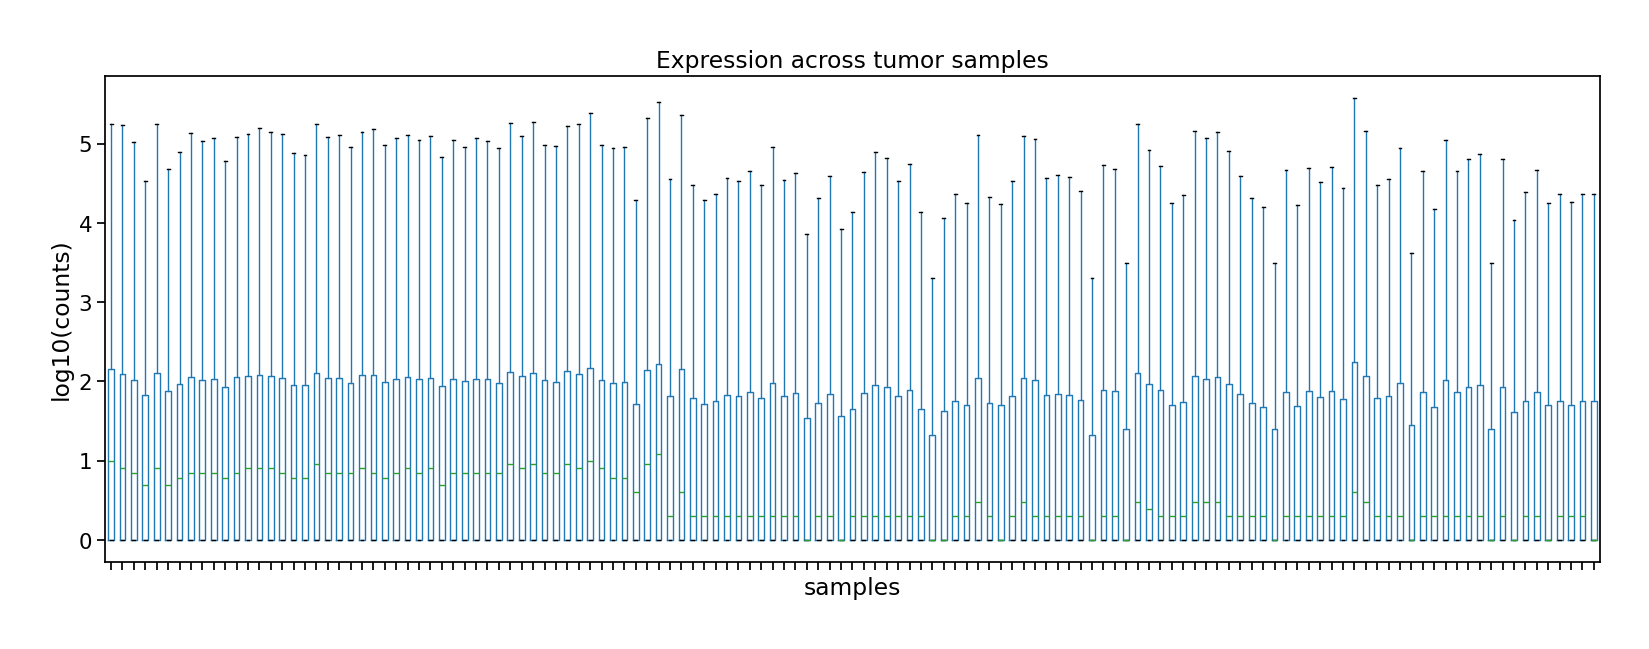

In [13]:
%matplotlib inline
cbio.plot_boxplot_expression(dfn_tumor, do_log10=True, title = "Expression across tumor samples")

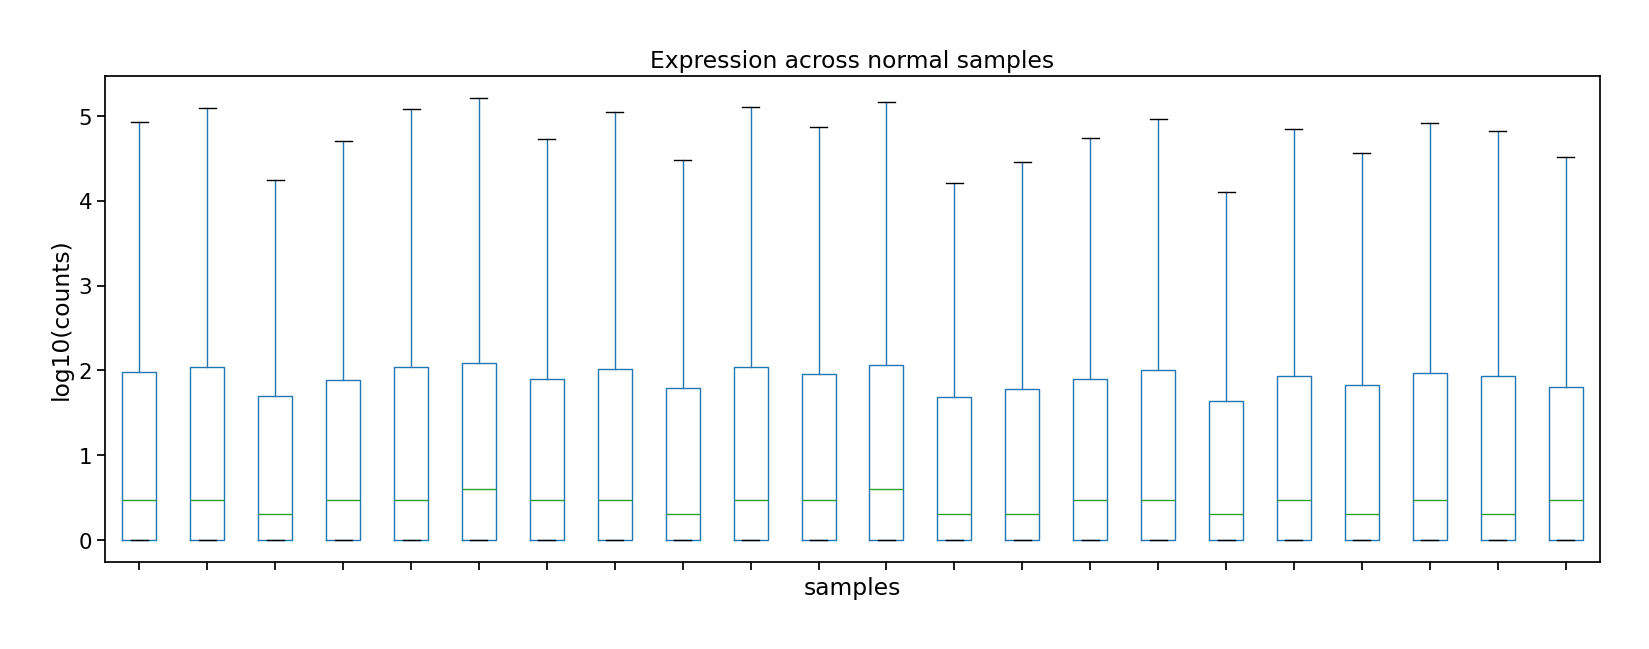

In [14]:
%matplotlib inline
cbio.plot_boxplot_expression(dfn_normal, do_log10=True, title = "Expression across normal samples")

### Bulk - by geneid

In [15]:
force=False
verbose=True

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=force, verbose=verbose)

#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

Table opened ((27177, 153)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism/bulk_matrix_geneid.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism/bulk_metadata_geneid.tsv'
(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


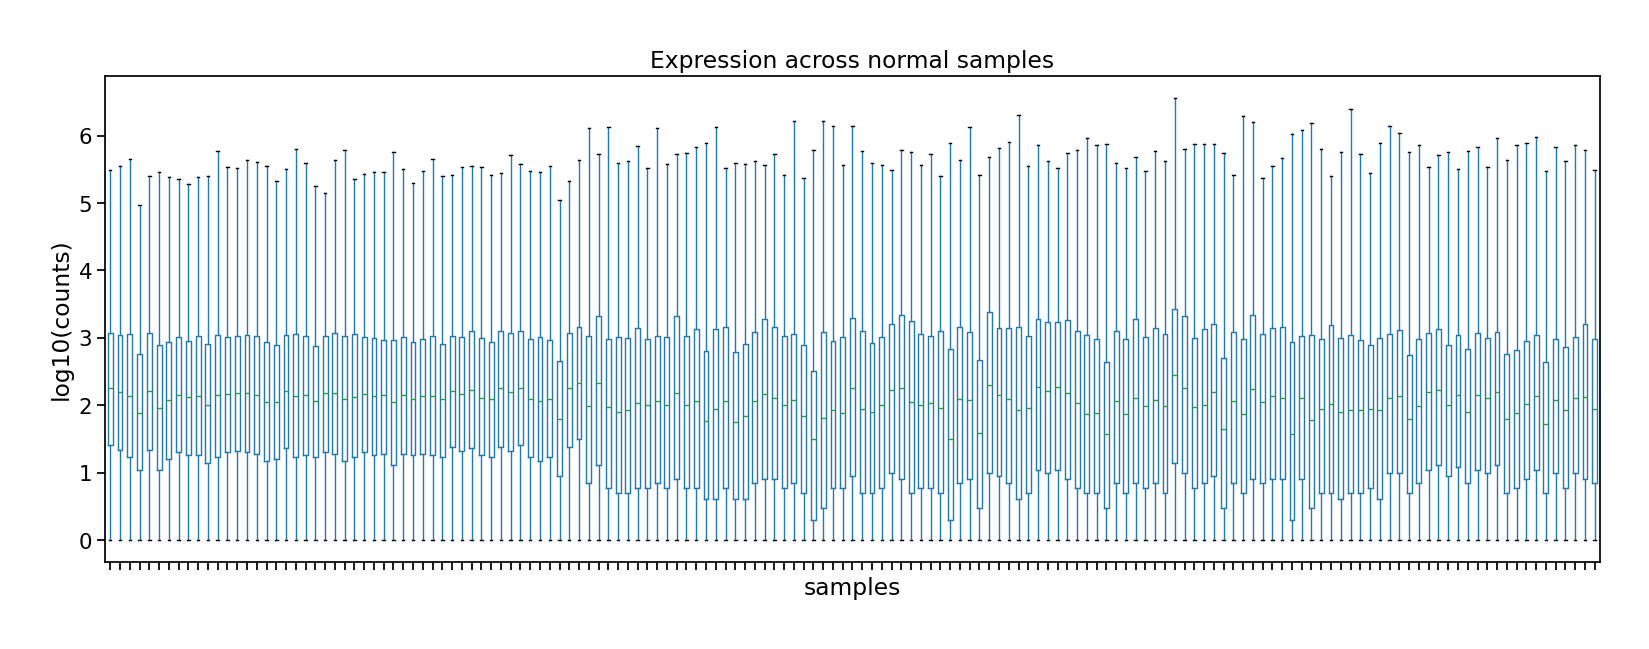

In [16]:
%matplotlib inline
cbio.plot_boxplot_expression(df_bulk, do_log10=True, title = "Expression across normal samples")

### Prism single-cell data reference - scAtlas 2005

In [17]:
import importlib, libs.prism_lib as prism_lib
importlib.reload(prism_lib)
print(prism_lib.__version__)

1.2.5


In [18]:
prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, dstudy=dstudy, verbose=verbose)

prism.root_prism, prism.root_prism.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

---------- Bayes Prism -------------
>> root m.project: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD
>> root d.study: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025
>> root m.p.prism: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism
>> root m.p.lfc: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/lfc
>> root m.p.tahoe: /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/tahoe

------- TCGA, CPTAC3, ... ------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/fla

(PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism'),
 True)

In [19]:
force=False
verbose=True

fname_ad = 'scAtlas_noPeng_noMet.h5ad'
filename_ad = prism.root_prism / fname_ad
compression = "gzip"

import anndata as ad
adata = ad.read_h5ad(filename_ad)


In [20]:
adata.obs_names[:5]

Index(['AAACATACTCGTTT-1_1', 'AAACCGTGGGTAGG-1_1', 'AAAGCAGACTGAGT-1_1', 'AAAGGCCTGCTCCT-1_1',
       'AAATACTGTGGATC-1_1'],
      dtype='object')

In [21]:
verbose=False
fname_celltype = "atlas_meta_noPeng_noMet.tsv"
adata_ct = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

adata_ct

AnnData object with n_obs × n_vars = 521758 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'Count', 'Study..Citation..PMID.', 'GSE.SRA..Study.', 'Name', 'If.metastatic..location', 'Clusters', 'Treatment', 'DiseaseState', 'TreatmentType', 'cluster', 'cell_type', 'cell_state'
    layers: 'counts'

### Reference

In [22]:
sk, tk = "cell_state", "cell_type"    # confirm the real key names used by pseudobulk_reference
m = adata_ct.obs[[sk, tk]].astype(str).drop_duplicates()
dup = m[m[sk].duplicated(keep=False)].sort_values(sk)
print(dup)                            # states mapping to >1 type — the offenders

Empty DataFrame
Columns: [cell_state, cell_type]
Index: []


In [23]:
cyc = {"CYCLING DUCTAL":"DUCTAL","CYCLING TNK":"TNK","CYCLING. MYELOID":"MYELOID"}
for col in ("cell_state", "cell_type"):        # whichever two keys pseudobulk_reference uses
    if col in adata_ct.obs:
        adata_ct.obs[col] = adata_ct.obs[col].astype(str).replace(cyc)

# make them categorical-clean and confirm 1:1 state->type
pair = adata_ct.obs[["cell_state","cell_type"]].astype(str).drop_duplicates()
assert not pair["cell_state"].duplicated().any(), pair[pair["cell_state"].duplicated(keep=False)]
print(pair.sort_values("cell_state"))          # expect 11 rows, state==type

ref, s2t = prism.pseudobulk_reference(adata_ct)
ref.shape                              # expect (11, ~36k)

                     cell_state    cell_type
AAGCGACTGAGGCA-1_1       ACINAR       ACINAR
AATTCCTGCTGATG-1_1      B CELLS      B CELLS
AAACATACTCGTTT-1_1       DUCTAL       DUCTAL
ACTGTGGACTGAAC-1_1    ENDOCRINE    ENDOCRINE
ACGTGCCTTGAGAA-1_1  ENDOTHELIAL  ENDOTHELIAL
AAACCGTGGGTAGG-1_1  FIBROBLASTS  FIBROBLASTS
AGACGTACTCAGGT-1_1         MAST         MAST
AACGTCGAACCACA-1_1      MYELOID      MYELOID
AACAGCACGACGGA-1_1    PERICYTES    PERICYTES
AACATATGTGGAAA-1_1       PLASMA       PLASMA
ACCCTCGACGGGAA-1_1          TNK          TNK


(11, 36380)

In [24]:
s2t

cell_state
DUCTAL              DUCTAL
FIBROBLASTS    FIBROBLASTS
PERICYTES        PERICYTES
PLASMA              PLASMA
MYELOID            MYELOID
ACINAR              ACINAR
B CELLS            B CELLS
TNK                    TNK
ENDOTHELIAL    ENDOTHELIAL
ENDOCRINE        ENDOCRINE
MAST                  MAST
Name: cell_type, dtype: object

In [25]:
s2t.value_counts()

cell_type
DUCTAL         1
FIBROBLASTS    1
PERICYTES      1
PLASMA         1
MYELOID        1
ACINAR         1
B CELLS        1
TNK            1
ENDOTHELIAL    1
ENDOCRINE      1
MAST           1
Name: count, dtype: int64

###  nnls_deconvolve()

It's the baseline cross-check — deliberately not part of the main path. It's there so you can ask "is my reference sane?" without trusting the engine you're validating.

What it computes. For each sample independently, it solves

min_w  ||Φᵀw − b_s||²    subject to  w ≥ 0

where b_s is the sample's CPM vector and Φᵀ is the genes × states signature matrix (each state row CPM-normalized). Then it rescales w to sum to 1. That's the dtangle / CIBERSORT family: linear unmixing under a Gaussian loss.

How it differs from prism_em, which matters more than it looks:

|	      | nnls_deconvolve	 |prism_em |
|---------|------------------|---------|
| loss	  | L2 on CPM	| multinomial on counts |
| gene weighting | high-expression genes dominate | Poisson variance weights each gene naturally |
| simplex	|  imposed post hoc by rescaling | enforced every iteration |
| malignant reference | fixed | sample-specific (stage 2) |

The L2-on-CPM part is the substantive difference. A gene at 5,000 CPM contributes ~10⁶× more residual than one at 5 CPM, so NNLS is effectively fit on a few dozen highly-expressed genes regardless of how informative they are. The multinomial likelihood weights each gene by its own expected count, which is the correct variance model for counts.

Why you'd actually run it. Concordance is a reference-quality diagnostic, and the pattern of disagreement is informative:

Stromal/immune states agree closely (Spearman > 0.8) → reference is fine
Stromal/immune states disagree → your phi is broken, or select_genes picked protocol-driven genes; fix that before interpreting anything
Malignant compartment disagrees while the rest agrees → expected and good. That's stage 2 doing its job. If NNLS and EM agree on purity, update_malignant_reference isn't contributing and PDAC classical/basal heterogeneity is still leaking into the stromal fractions

To wire it in:

In [26]:
ref.head(2)

,MIR1302-2HG,FAM138A,OR4F5,AL627309.1,AL627309.3,AL627309.2,AL627309.5,AL627309.4,AP006222.2,AL732372.1,...,AC133551.1,AC136612.1,AC136616.1,AC136616.3,AC136616.2,AC141272.1,AC023491.2,AC007325.1,AC007325.4,AC007325.2
cell_state,,,,,,,,,,,,,,,,,,,,,
DUCTAL,1.0,0.0,2.0,250.0,13.0,0.0,2157.0,37.0,167.0,6.0,...,0.0,2.0,11.0,0.0,0.0,0.0,6.0,9.0,2362.0,745.0
FIBROBLASTS,0.0,0.0,0.0,37.0,2.0,0.0,131.0,1.0,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,4.0,27.0,821.0,9.0


In [27]:
df_bulk.head(2)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


In [28]:
#--- reference geneid --> 
# gene_map = prism.load_gene_map("geneid")
bulk_symbs = gene_map.loc[df_bulk.index.to_list()]
bulk_symbs.head(3)

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding
ENSG00000000419,DPM1,protein_coding


### ref_new --> new reference, by geneid (ensbeml)

In [29]:
force=False
verbose=True

# ref, s2t = prism.pseudobulk_reference(adata_ct)

ref_new, df_to_from = prism.harmonize_reference_to_ensembl(bulk_symbs=bulk_symbs, ref=ref, gene_map=gene_map, force=force, verbose=verbose)

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.iloc[:, :5]

Table opened ((11, 26119)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism/ref_new_geneid.tsv'
Table opened ((36380, 5)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism/to_from_table.tsv'
(11, 26119)
status
ok               26119
no_ensembl_id    10261
Name: count, dtype: int64


,ENSG00000241860,ENSG00000237491,ENSG00000177757,ENSG00000228794,ENSG00000225880
cell_state,,,,,
DUCTAL,2157.0,5932.0,21.0,8051.0,2051.0
FIBROBLASTS,131.0,1213.0,145.0,3648.0,408.0
PERICYTES,52.0,512.0,53.0,1047.0,126.0
PLASMA,3.0,84.0,0.0,35.0,21.0
MYELOID,670.0,1300.0,54.0,3269.0,570.0
ACINAR,372.0,610.0,3.0,1092.0,186.0
B CELLS,29.0,268.0,5.0,149.0,57.0
TNK,137.0,1785.0,24.0,2375.0,630.0
ENDOTHELIAL,79.0,397.0,16.0,1484.0,203.0


In [30]:
df_to_from[df_to_from.renamed].head(3)

,ref_symbol,current_symbol,geneid,status,renamed
733,YARS,YARS1,ENSG00000134684,ok,True
787,ADPRHL2,ADPRS,ENSG00000116863,ok,True
1245,WDR78,DNAI4,ENSG00000152763,ok,True


In [31]:
df_to_from2 = df_to_from[~pd.isnull(df_to_from.geneid)]
df_to_from2

,ref_symbol,current_symbol,geneid,status,renamed
6,AL627309.5,AL627309.5,ENSG00000241860,ok,False
14,LINC01409,LINC01409,ENSG00000237491,ok,False
15,FAM87B,FAM87B,ENSG00000177757,ok,False
16,LINC01128,LINC01128,ENSG00000228794,ok,False
17,LINC00115,LINC00115,ENSG00000225880,ok,False
...,...,...,...,...,...
36309,KDM5D,KDM5D,ENSG00000012817,ok,False
36310,AC010889.2,AC010889.2,ENSG00000288049,ok,False
36311,TTTY10,TTTY10,ENSG00000229236,ok,False
36312,EIF1AY,EIF1AY,ENSG00000198692,ok,False


In [32]:
gene_subset = prism.select_genes(ref_new)
len(gene_subset), gene_subset[:5]

(2200,
 ['ENSG00000000938',
  'ENSG00000001617',
  'ENSG00000002745',
  'ENSG00000002746',
  'ENSG00000003987'])

In [33]:
print(type(s2t), len(s2t))
s2t

<class 'pandas.core.series.Series'> 11


cell_state
DUCTAL              DUCTAL
FIBROBLASTS    FIBROBLASTS
PERICYTES        PERICYTES
PLASMA              PLASMA
MYELOID            MYELOID
ACINAR              ACINAR
B CELLS            B CELLS
TNK                    TNK
ENDOTHELIAL    ENDOTHELIAL
ENDOCRINE        ENDOCRINE
MAST                  MAST
Name: cell_type, dtype: object

### Removing bad columns - see mtp_cBIO_66_PAAD_batch_and_samples_to_remove

In [34]:
cols = df_bulk.columns
cols

Index(['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701', 'T-C3L-04072', 'T-C3L-00589', 'T-C3L-03123',
       'T-C3N-01383', 'T-C3L-01124', 'T-C3L-00625', 'T-C3N-03439',
       ...
       'N-C3N-03069', 'N-C3N-02765', 'N-C3L-07037', 'N-C3N-02589', 'N-C3N-02996', 'N-C3L-02606',
       'N-C3N-03173', 'N-C3N-02696', 'N-TCGA-H6-8124', 'N-TCGA-H6-A45N'],
      dtype='object', length=153)

In [35]:
print(df_bulk.shape)
df_bulk.head(2)

(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


In [36]:
adata.obs.columns

Index(['nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'Count',
       'Study..Citation..PMID.', 'GSE.SRA..Study.', 'Name', 'If.metastatic..location', 'Clusters',
       'Treatment', 'DiseaseState', 'TreatmentType'],
      dtype='object')

In [37]:
adata.obs.head(3).T

,AAACATACTCGTTT-1_1,AAACCGTGGGTAGG-1_1,AAAGCAGACTGAGT-1_1
nCount_RNA,2480,690,1670
nFeature_RNA,962,338,623
percent.mt,12.661,2.174,2.156
seurat_clusters,4,3,3
Count,241,241,241
Study..Citation..PMID.,"Lin W, Noel P, Borazanci EH, Lee J et al. Single-cell transcriptome analysis...","Lin W, Noel P, Borazanci EH, Lee J et al. Single-cell transcriptome analysis...","Lin W, Noel P, Borazanci EH, Lee J et al. Single-cell transcriptome analysis..."
GSE.SRA..Study.,GSE154778,GSE154778,GSE154778
Name,T1,T1,T1
If.metastatic..location,NaN,NaN,NaN
Clusters,DUCTAL,FIBROBLASTS,FIBROBLASTS


In [38]:
np.unique(adata.obs['Study..Citation..PMID.'].to_list())

array(['Carpenter et al Cancer Discovery',
       'Chan-Seng-Yue, M., Kim, J.C., Wilson, G.W.\xa0et al.\xa0Transcription phenotypes of pancreatic cancer are driven by genomic events during tumor evolution.\xa0Nat Genet\xa052, 231–240 (2020). https://doi.org/10.1038/s41588-019-0566-9 PMID: 31932696',
       'Elyada E, Bolisetty M, Laise P, Flynn WF, Courtois ET, Burkhart RA, Teinor JA, Belleau P, Biffi G, Lucito MS, Sivajothi S, Armstrong TD, Engle DD, Yu KH, Hao Y, Wolfgang CL, Park Y, Preall J, Jaffee EM, Califano A, Robson P, Tuveson DA. Cross-Species Single-Cell Analysis of Pancreatic Ductal Adenocarcinoma Reveals Antigen-Presenting Cancer-Associated Fibroblasts. Cancer Discov. 2019 Aug;9(8):1102-1123. doi: 10.1158/2159-8290.CD-19-0094. Epub 2019 Jun 13. PMID: 31197017',
       'Lee et al Clinical Cancer Research',
       'Lin W, Noel P, Borazanci EH, Lee J et al. Single-cell transcriptome analysis of tumor and stromal compartments of pancreatic ductal adenocarcinoma primary tumors 

In [39]:
gse_studies = list(adata.obs['GSE.SRA..Study.'].unique())
gse_studies

['GSE154778',
 'GSE156405',
 'GSE194247',
 'GSE202051',
 'GSE205013',
 'GSE211644',
 'EGAS00001002543',
 'phs001840.v1.p1',
 'GSE155698',
 'GSE229413']

### calc bayesprism

In [40]:
verbose=True
force=False

meta_desc = dict(reference="scAtlas-2005",
              cohorts=gse_studies,
              strand="unknown",
              method="InstaPrism")

gene_subset = prism.select_genes(ref_new)

res = prism.run_bayesprism(df_bulk=df_bulk, ref=ref_new, state_to_type=s2t,
                           gene_subset=gene_subset, meta_desc=meta_desc, force=force, verbose=verbose)

type(res)

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/scAtlas2025/prism/deconv.h5ad (12.8 MB)


libs.prism_lib.DeconvResult

In [41]:
df_bulk.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5
ENSG00000000419,1330,1521,1499,986,1388,974,649,1171,1120,1428,...,703,601,1059,1289,342,773,676,783,1532,1023


In [42]:
df_nnls = prism.nnls_deconvolve(df_bulk, ref_new, genes=res.genes)
print(df_nnls.shape)

df_nnls.head(5)

(153, 11)


cell_state,DUCTAL,FIBROBLASTS,PERICYTES,PLASMA,MYELOID,ACINAR,B CELLS,TNK,ENDOTHELIAL,ENDOCRINE,MAST
T-C3L-02890,0.052,0.767,0.045,0.000,0.000,0.134,0.000,0.0,0.000,0.001,0.000
T-C3L-03635,0.009,0.984,0.005,0.000,0.000,0.000,0.000,0.0,0.000,0.002,0.000
T-C3L-02701,0.005,0.961,0.028,0.000,0.000,0.000,0.000,0.0,0.000,0.005,0.000
T-C3L-04072,0.172,0.691,0.041,0.005,0.015,0.000,0.000,0.0,0.075,0.000,0.000
T-C3L-00589,0.229,0.604,0.042,0.005,0.024,0.000,0.019,0.0,0.071,0.001,0.005


### Maligant Cluster

In [43]:
import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.35.0


In [44]:
df_theta = res.theta
df_theta.head(5)

,DUCTAL,FIBROBLASTS,PERICYTES,PLASMA,MYELOID,ACINAR,B CELLS,TNK,ENDOTHELIAL,ENDOCRINE,MAST
T-C3L-02890,0.304,0.549,0.013,0.010,0.048,0.006,0.009,8.810e-03,0.036,1.527e-02,0.002
T-C3L-03635,0.162,0.703,0.006,0.003,0.038,0.000,0.014,7.513e-03,0.049,1.667e-02,0.001
T-C3L-02701,0.150,0.698,0.001,0.006,0.059,0.000,0.006,7.338e-04,0.033,4.305e-02,0.002
T-C3L-04072,0.362,0.356,0.012,0.045,0.141,0.000,0.010,1.032e-02,0.060,3.185e-110,0.003
T-C3L-00589,0.414,0.388,0.047,0.005,0.068,0.000,0.011,3.882e-03,0.048,1.038e-02,0.005


In [45]:
root_mprog_disease = cbio.root_mprog_disease
mal_cell_name = "DUCTAL"
organ="Pancreas"

mc = pml.MalignantCluster(prism=prism, res=res, 
                          df_bulk=df_bulk, ref=ref_new, 
                          root_mprog_disease = root_mprog_disease,
                          mal_cell_name = mal_cell_name,
                          organ=organ)

mc

In [46]:
samples = df_theta.index.to_list()
len(samples), samples[-5:]

(153,
 ['N-C3L-02606',
  'N-C3N-03173',
  'N-C3N-02696',
  'N-TCGA-H6-8124',
  'N-TCGA-H6-A45N'])

In [47]:
df_theta = res.theta
tumor_samp_all = [s for s in df_theta.index if s.startswith("T-")]
failed = df_theta.index[df_theta.isna().all(axis=1) | (df_theta.max(axis=1) > 0.98)].tolist()
bad_now = [s for s in tumor_samp_all if s in failed]
print("bad tumors now:", len(bad_now), "| was ~22")
tumor_samples = [s for s in tumor_samp_all if s not in bad_now]   # rebuild on clean theta
print("tumor_samples:", len(tumor_samples))

df_theta_tumor = mc.df_theta.loc[tumor_samples].round(5)
print(df_theta_tumor.shape)
df_theta_tumor.head(3)

bad tumors now: 2 | was ~22
tumor_samples: 129
(129, 11)


,DUCTAL,FIBROBLASTS,PERICYTES,PLASMA,MYELOID,ACINAR,B CELLS,TNK,ENDOTHELIAL,ENDOCRINE,MAST
T-C3L-02890,0.304,0.549,0.013,0.010,0.048,0.006,0.009,8.810e-03,0.036,0.015,0.002
T-C3L-03635,0.162,0.703,0.006,0.003,0.038,0.000,0.014,7.510e-03,0.049,0.017,0.001
T-C3L-02701,0.150,0.698,0.001,0.006,0.059,0.000,0.006,7.300e-04,0.033,0.043,0.002


In [48]:
normal_samples = [x for x in res.theta.index if x.startswith("N-")]

df_theta_normal = mc.df_theta.loc[normal_samples].round(5)
print(df_theta_normal.shape[0])
df_theta_normal.head(3)

22


,DUCTAL,FIBROBLASTS,PERICYTES,PLASMA,MYELOID,ACINAR,B CELLS,TNK,ENDOTHELIAL,ENDOCRINE,MAST
N-C3L-04072,0.046,0.125,0.011,3.370e-03,0.041,0.741,4.330e-03,0.004,0.020,0.004,1.040e-03
N-C3L-00589,0.686,0.043,0.062,8.713e-02,0.062,0.000,0.000e+00,0.013,0.031,0.004,1.284e-02
N-C3L-03123,0.000,0.008,0.002,1.000e-05,0.001,0.982,1.500e-04,0.000,0.005,0.001,1.400e-04


In [49]:
mc.Z_full.shape

(153, 11, 26119)

### THE GATE: does malignant theta now look like a tumour?

In [50]:
duc = res.theta["DUCTAL"]
print("DUCTAL theta — median", round(duc.median(),3),
      "| frac>=0.3", round((duc>=0.3).mean(),2),
      "| frac=].03,02]", round(( (duc<0.3)&(duc>=0.02)).mean(),2),
      "| frac<0.02", round((duc<0.02).mean(),2),
      "| n underflow(<1e-6)", round((duc<1e-6).mean(),2))

DUCTAL theta — median 0.229 | frac>=0.3 0.41 | frac=].03,02] 0.49 | frac<0.02 0.1 | n underflow(<1e-6) 0.08


In [51]:
duc = df_theta_tumor["DUCTAL"]
print("DUCTAL theta — median", round(duc.median(),3),
      "| frac>=0.3", round((duc>=0.3).mean(),2),
      "| frac=].03,02]", round(( (duc<0.3)&(duc>=0.02)).mean(),2),
      "| frac<0.02", round((duc<0.02).mean(),2),
      "| n underflow(<1e-6)", round((duc<1e-6).mean(),2))


DUCTAL theta — median 0.271 | frac>=0.3 0.45 | frac=].03,02] 0.5 | frac<0.02 0.05 | n underflow(<1e-6) 0.04


In [52]:
gene_map_symb = gene_map.reset_index().set_index('symbol')
gene_map_symb.head(3)

,geneid,biotype
symbol,,
TSPAN6,ENSG00000000003,protein_coding
TNMD,ENSG00000000005,protein_coding
DPM1,ENSG00000000419,protein_coding


In [53]:
PROLIF_GENES = mc.PROGRAMS["malignant"]["prolif"]
ICAF_GENES = mc.PROGRAMS["fibroblast"]["iCAF"]

PROLIF_GENES_geneid = gene_map_symb.loc[PROLIF_GENES].geneid.to_list()
ICAF_GENES_geneid = gene_map_symb.loc[ICAF_GENES].geneid.to_list()

print(">>> prolif:", PROLIF_GENES)
print(">>> iCAF:  ", ICAF_GENES)

>>> prolif: ['MKI67', 'TOP2A', 'CCNB1', 'AURKA', 'BIRC5', 'PLK1']
>>> iCAF:   ['DPT', 'IL6', 'CXCL12', 'PDGFRA', 'HAS1', 'HAS2', 'CFD', 'LMNA', 'C3', 'CXCL14']


In [54]:
MIN_SHARE, MIN_COUNTS = 0.3, 10

cmap = {
    "malignant":   "DUCTAL",
    "fibroblast":  "FIBROBLASTS",
    "myeloid":     "MYELOID",        # NOT "macrophage": MYELOID ⊃ mono/DC/neutrophil
    "endothelial": "ENDOTHELIAL",
    "acinar":      "ACINAR",
}

df_theta_tumor = mc.df_theta.loc[tumor_samples]
batch = pd.Series(np.where(df_theta_tumor.index.str.contains("TCGA"), "TCGA", "CPTAC"), index=tumor_samples, name="cohort")

assert list(batch.index) == list(tumor_samples)
assert batch.nunique() == 2, batch.value_counts()   # confirm both cohorts present in tumor set
print(batch.value_counts())

X_duc2 = mc.compartment_matrix(cmap["malignant"],  min_share=MIN_SHARE, min_counts=MIN_COUNTS,
                               batch=batch, samples=tumor_samples, verbose=False)
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=MIN_SHARE, min_counts=MIN_COUNTS,
                               batch=batch, samples=tumor_samples, verbose=False)



cohort
TCGA     80
CPTAC    49
Name: count, dtype: int64


In [55]:
paired = X_duc2.index.intersection(X_fib2.index)
pb = pd.Series(np.where(paired.str.contains("TCGA"),"TCGA","CPTAC"))
print("paired N:", pb.value_counts().to_dict())     # CPTAC should climb toward ~66

for name, g, X in [("prolif", PROLIF_GENES_geneid, X_duc2), ("iCAF", ICAF_GENES_geneid, X_fib2)]:
    present = [x for x in g if x in X.columns]      # X is samples x genes -> genes on columns
    print(f"{name}: {len(present)}/{len(g)} panel genes in matrix")
    if len(present) < len(g):
        print("   missing:", [x for x in g if x not in X.columns][:10])

paired N: {'TCGA': 74, 'CPTAC': 48}
prolif: 6/6 panel genes in matrix
iCAF: 10/10 panel genes in matrix


In [56]:
# proliferation score from malignant Z, iCAF score from fibroblast Z
# (use the SAME gene sets as the Peng run for like-for-like)
prolif = prism.score_signature(X_duc2.T, PROLIF_GENES_geneid, log=False)
icaf   = prism.score_signature(X_fib2.T, ICAF_GENES_geneid,   log=False)

In [57]:
paired = X_duc2.index.intersection(X_fib2.index)

rows = []
for coh in ("TCGA","CPTAC"):
    idx = [s for s in paired if (("TCGA" in s)==(coh=="TCGA"))]
    r,p = pearsonr(prolif.loc[idx], icaf.loc[idx])
    rows.append((coh, len(idx), r, p))
    print(f"{coh}: n={len(idx)} r={r:+.3f} p={p:.2e}")

# Fisher-z meta
z  = [np.arctanh(r) for _,n,r,_ in rows]
w  = [n-3 for _,n,_,_ in rows]
zbar = np.sum(np.multiply(z,w))/np.sum(w)
r_meta = np.tanh(zbar)
se = np.sqrt(1/np.sum(w)); zstat = zbar/se
from scipy.stats import norm
print(f"meta r={r_meta:+.3f}  p={2*norm.sf(abs(zstat)):.2e}")
# I^2 across the two cohorts
Q = np.sum([wi*(zi-zbar)**2 for zi,wi in zip(z,w)])
I2 = max(0,(Q-1)/Q)*100
print(f"I²={I2:.0f}%")

TCGA: n=74 r=-0.066 p=5.78e-01
CPTAC: n=48 r=-0.149 p=3.13e-01
meta r=-0.098  p=2.89e-01
I²=0%


That's the clean, correct computation:

 raw program scores on the theta/lib/batch-decoupled compartment matrices, per cohort, Fisher-z meta. No degenerate residualization, no double-log, full panel coverage, both compartments passing identifiability. This is the number.

**The iCAF–proliferation coupling does not replicate on the scAtlas-2025 reference.** TCGA −0.066 (p=0.58), CPTAC −0.149 (p=0.31), meta −0.098 (p=0.29), I²=0. Against the Peng baseline of −0.462/−0.505/−0.476, the effect is gone — not attenuated, gone, and consistently absent across two independent cohorts.

What makes this a *strong* negative rather than a failed run — every alternative explanation has been ruled out in the course of getting here:

- **Not a deconvolution artifact**: 
  - DUCTAL collapsed, you diagnosed it to a stale harmonization, fixed it, 
  - θ is now tumor-shaped (median 0.271, 5% underflow).
- **Not an identifiability problem**: 
  - EM-vs-NNLS concordance gives 
    - DUCTAL ρ=0.849 (≈ Peng's 0.850) and 
    - FIBROBLASTS ρ=0.960 (≈ Peng's 0.929). 
  - Both load-bearing compartments are as recoverable here as in Peng.
- **Not a measurement failure**: 
  - the proliferation program tracks MKI67/TOP2A/CCNB1/CENPF at 0.85–0.90; the signal is real and well-defined.
- **Not batch**: 
  - decoupled in `compartment_matrix` and controlled again by per-cohort stratification;
  - I²=0 shows the two cohorts agree.
- **Not panel or coverage**: 
  - 6/6 and 10/10 genes present.

So the coupling isn't hiding behind any technical defect. The compartments are healthy, the programs are genuine, and they simply aren't correlated on this reference.

**The one remaining interpretation to pin down — and it's biological, not technical.** The Peng malignant compartment was "Ductal cell type 2," explicitly *malignant* ductal. The atlas pools all ductal (malignant + normal-adjacent + treated + nine collapsed Loveless states) into one DUCTAL. Proliferation tracks MKI67 fine in that pool — but proliferation-in-pooled-ductal ≠ proliferation-in-malignant-epithelium. The decisive experiment is the DUCTAL subcluster: split malignant (high-CNV, basal/classical) from normal ductal, re-score proliferation on malignant-only, re-correlate.

- Coupling **reappears** on malignant-only → Peng's finer malignant labeling was necessary; the finding holds with a caveat that the atlas's coarse DUCTAL masks it. The result becomes "reference-granularity-dependent," not "false."
- Coupling **stays null** → it's genuinely Peng-reference-specific and doesn't generalize to an integrated atlas. Clean, publishable negative.

That's the only test that separates "the atlas is too coarse to see it" from "the coupling was Peng-specific," and until you run it those two are confounded. It's the subclustering you'd already flagged as on-the-horizon — now it's the interpretive crux.

One provenance caveat before you write either version up: confirm the Peng −0.462 was computed the same way — raw scores on decoupled matrices with stage-2 enabled. You settled on raw-scores-on-decoupled here; if Peng matches, it's like-for-like and the comparison is sound. (You seem to have concluded it does, since you ran the raw version as final — good.)

This is exactly why the reference swap was worth doing. A finding that survives θ-control, bootstrap, permutation, and both cohorts but **not** an independent reference is precisely what this experiment was designed to surface. Whichever way the subcluster test goes, you now have a real, defensible result — either a bounded, honest claim or a clean negative — instead of an overgeneralized one.

Want the DUCTAL malignant/normal subcluster + inferCNV split next? That's the last experiment before this is writeable.

### trips loudly next time a stale ref sneaks through

In [58]:
mc.assert_malignant_sane(res=res, mal="DUCTAL", min_median=0.05, max_underflow=0.20)   

{'median': 0.229, 'frac_ge_0_3': 0.41, 'underflow': 0.08}

In [59]:
assert list(batch.index) == list(tumor_samples)
assert batch.nunique() == 2, batch.value_counts()   # confirm both cohorts present in tumor set
print(batch.value_counts())

zeros = (df_theta_tumor == 0).sum(axis=1)
print(zeros.value_counts().sort_index().to_dict())

bad_tumors = df_theta_tumor[zeros >= 3].T
print("\nAre there bad tumor samples?")
bad_tumors

cohort
TCGA     80
CPTAC    49
Name: count, dtype: int64
{0: 43, 1: 69, 2: 17}

Are there bad tumor samples?


""
DUCTAL
FIBROBLASTS
PERICYTES
PLASMA
MYELOID
ACINAR
B CELLS
TNK
ENDOTHELIAL
ENDOCRINE


In [60]:
X_fib2.iloc[:3, :5]

,ENSG00000000003,ENSG00000000419,ENSG00000000460,ENSG00000000971,ENSG00000001036
T-C3L-02890,5.534,5.130,3.124,8.601,5.997
T-C3L-03635,5.974,5.248,3.675,8.389,5.669
T-C3L-02701,5.604,5.243,2.315,8.184,6.241


In [61]:
print("in :", batch.value_counts().to_dict())            # {'TCGA':84,'CPTAC':69}
kept=X_fib2.index
print("len(kept):", len(kept))
kb = pd.Series(np.where(kept.str.contains("TCGA"), "TCGA", "CPTAC"))
print("out for fibroblasts:", kb.value_counts().to_dict())

in : {'TCGA': 80, 'CPTAC': 49}
len(kept): 126
out for fibroblasts: {'TCGA': 77, 'CPTAC': 49}


Consistent and clean. `batch` is on the 129 tumor set (80/49), fibroblast compartment keeps 126 (77/49) — the 3 TCGA lost to `min_theta` (fibroblast θ < 0.02), CPTAC fully retained. This matches everything from the healed run; nothing has drifted.

So the accounting across the whole pipeline is coherent:
- tumor_samples: 129 (80 TCGA / 49 CPTAC)
- FIBROBLASTS compartment: 126 (77/49)
- DUCTAL compartment: ~122 (74/48)
- paired (both estimable): 122 (74/48) — what the correlation runs on

No stale objects, no sample-basis mismatch. The −0.098 is computed on the right set.

At this point you've verified the plumbing from every angle — sample counts, batch alignment, compartment retention, identifiability, panel coverage, program validity. All green. The result is solid: **the coupling doesn't replicate on scAtlas-2025, meta r=−0.098, I²=0**, with every technical confound excluded.

There's genuinely nothing left to re-check on the deconvolution side. The remaining moves are interpretive/scientific, not diagnostic:

1. **DUCTAL malignant/normal subcluster** (inferCNV or inferCNVpy) → re-score proliferation on malignant-only → re-correlate. This is the one experiment that tells you whether the null is "atlas DUCTAL too coarse" vs "coupling is Peng-specific." It's the interpretive crux and the last thing standing between you and a writeable result.

2. **Confirm the Peng −0.462 provenance** — raw scores on decoupled matrices, stage-2 on — so the comparison is documented as like-for-like.

If you keep re-running sample-count checks, they'll keep coming back consistent — you've already confirmed this three times from different angles. The counts are right. Time to either run the subcluster test or write up the negative.

Want the inferCNVpy malignant/normal split for DUCTAL? That's the decisive next step.

In [62]:
# 1. is the gate cutting the low-fibroblast tail symmetrically, or clipping one cohort's range?
fib = df_theta_tumor["FIBROBLASTS"]
for coh in ("TCGA","CPTAC"):
    m = fib.index.str.contains("TCGA") == (coh=="TCGA")
    s = fib[m & fib.index.isin(tumor_samples)]
    print(coh, "median", round(s.median(),3), "frac<0.3", round((s<MIN_SHARE).mean(),2))

TCGA median 0.352 frac<0.3 0.44
CPTAC median 0.447 frac<0.3 0.16


In [63]:
tum = df_theta_tumor.index

for coh in ("TCGA","CPTAC"):
    m = tum[(tum.str.contains("TCGA")) == (coh=="TCGA")]
    passes_share = fib[m] >= MIN_SHARE
    print(coh,
          "n_in", len(m),
          "pass_share", int(passes_share.sum()),          # survivors if share were the ONLY gate
          "kept_actual", (kept.str.contains("TCGA")==(coh=="TCGA")).sum())

TCGA n_in 80 pass_share 45 kept_actual 77
CPTAC n_in 49 pass_share 41 kept_actual 49


In [64]:
X_duc2.head(3)

,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000001084,ENSG00000001167,ENSG00000001460,ENSG00000001461,ENSG00000001497,ENSG00000001561,...,ENSG00000287855,ENSG00000287860,ENSG00000287906,ENSG00000287917,ENSG00000287929,ENSG00000287966,ENSG00000287978,ENSG00000288073,ENSG00000288398,ENSG00000288559
T-C3L-02890,6.098,5.978,5.553,4.052,6.566,5.941,4.802,6.877,6.046,5.848,...,1.409,1.458,3.951,1.935,2.316,1.917,1.742,2.519,3.716,1.993
T-C3L-03635,6.413,6.044,6.270,4.615,6.020,6.277,4.410,6.773,5.370,5.250,...,0.961,2.035,3.762,0.947,3.092,1.758,2.489,2.329,3.357,1.632
T-C3L-02701,6.014,5.999,5.164,3.180,5.683,5.666,4.494,6.829,5.396,6.767,...,0.517,1.370,4.293,1.639,2.664,1.200,1.387,2.140,3.176,2.045


In [65]:
duct = df_theta_tumor["DUCTAL"]
tum = df_theta_tumor.index

kept=X_duc2.index

for coh in ("TCGA","CPTAC"):
    m = tum[(tum.str.contains("TCGA")) == (coh=="TCGA")]
    passes_share = duct[m] >= MIN_SHARE
    print(coh,
          "n_in", len(m),
          "pass_share", int(passes_share.sum()),          # survivors if share were the ONLY gate
          "kept_actual", (kept.str.contains("TCGA")==(coh=="TCGA")).sum())

TCGA n_in 80 pass_share 40 kept_actual 74
CPTAC n_in 49 pass_share 18 kept_actual 48


### Copy Number Variation ~ to assess Ductal Malignance

inferCNVpy (scanpy-native) is the right tool since you're in Python. Below is the full path: gene positions → diploid reference → CNV inference → malignant/normal split within DUCTAL. Read the decision notes, they matter more than the code.




In [66]:
import infercnvpy as cnv
import scanpy as sc

### Memory problems

In [67]:
# ---------------------------------------------------------------
# 0. Subset — don't run CNV on all 521k cells. You only need the
#    epithelium you're calling (DUCTAL, +ACINAR as an epithelial
#    sanity check) plus a DIPLOID reference. Immune cells are the
#    cleanest reference: reliably diploid, unlike AdjN which still
#    contains real epithelium.
# ---------------------------------------------------------------

ref_types  = ["TNK", "MYELOID", "B CELLS"]          # diploid reference
call_types = ["DUCTAL", "ACINAR"]                    # cells to classify
keep = adata_ct.obs["cell_type"].isin(ref_types + call_types)
adata_ct2 = adata_ct[keep].copy()

print(type(adata_ct2.X), adata_ct2.X.dtype if hasattr(adata_ct2.X,'dtype') else '')
print("shape:", adata_ct2.shape)
import scipy.sparse as sp
print("X sparse?", sp.issparse(adata_ct2.X),
      "| counts sparse?", sp.issparse(adata_ct2.layers.get("counts")))

<class 'scipy.sparse._csr.csr_matrix'> int64
shape: (393387, 36601)
X sparse? True | counts sparse? True


In [68]:
rng = np.random.default_rng(0)

def cap_idx(ad, ct, n):
    idx = np.where(ad.obs["cell_type"].values == ct)[0]
    return idx if len(idx) <= n else rng.choice(idx, n, replace=False)

keep_idx = np.sort(np.concatenate([
    cap_idx(adata_ct2, "DUCTAL",  40000),
    cap_idx(adata_ct2, "ACINAR",  10000),
    cap_idx(adata_ct2, "TNK",     15000),
    cap_idx(adata_ct2, "MYELOID", 10000),
    cap_idx(adata_ct2, "B CELLS",  5000),
]))
adata_ct2 = adata_ct2[keep_idx].copy()
print("after cap:", adata_ct2.shape)          # MUST print ~80000 x 36601

after cap: (80000, 36601)


In [69]:
# ---------------------------------------------------------------
# 1. Expression: infercnvpy wants log-normalized in .X (NOT raw).
#    Keep counts in a layer.
# ---------------------------------------------------------------

adata_ct2.X = adata_ct2.layers["counts"].astype("float32")   # float32 halves the peak

sc.pp.filter_genes(adata_ct2, min_cells=20)                  # ~36k -> ~18-20k genes
sc.pp.normalize_total(adata_ct2, target_sum=1e4)
sc.pp.log1p(adata_ct2)

print("ready:", adata_ct2.shape, adata_ct2.X.dtype)          # expect ~80000 x ~19000, float32

ready: (80000, 24294) float32


### GFF reference

inferCNV only needs each gene's chromosome and start coordinate to order genes along the genome. Gene positions (coordinates) are extremely stable across Ensembl releases within the same assembly — GRCh38 is GRCh38, and a gene's chromosomal location doesn't move between release 110 and 116. So 116 works for positioning. The only risk is gene-name matching: release 116 may use updated symbols (the HGNC renames you already hit — CCN/SEPTIN/MARCHF), so some atlas var_names won't match 116's gene_name and those genes drop from the CNV. That's tolerable (inferCNV averages over windows; losing a few percent of genes doesn't break it), but match on the same symbol vocabulary if you can. Since your atlas is GRCh38, any GRCh38 release is coordinate-correct.


```Bash
# GTF (this is the one infercnvpy's genomic_position_from_gtf parses)
wget https://ftp.ensembl.org/pub/release-110/gtf/homo_sapiens/Homo_sapiens.GRCh38.110.gtf.gz

# GFF3 (only if you want it for something else — infercnv doesn't need it)
# wget https://ftp.ensembl.org/pub/release-110/gff3/homo_sapiens/Homo_sapiens.GRCh38.110.gff3.gz
```

#### see: import_gtf.py

In [70]:
root_refseq = Path('/home/flavio/uv/perturb_agent/data/colab/refseq/')
fname = 'Homo_sapiens.GRCh38.110.gtf.gz'
filename = root_refseq / fname

root_refseq = cbio.root_colab / 'refseq'
[x for x in os.listdir(root_refseq) if '110.' in x]

['Homo_sapiens.GRCh38.110.gtf.gz']

In [71]:
fname2 = 'hsa_GRCh38_110_gtf_simple.tsv'
filename2 = root_refseq / fname2


dfgtf = pd.read_csv(filename2, sep='\t', index_col=0)
print(dfgtf.shape)          # expect ~30-40k genes for GTF release 110/116
dfgtf.head(3)

(40874, 3)


,chromosome,start,end
gene_name,,,
DDX11L17,chr1,182696,184174
PRDM16,chr1,3069168,3438621
PEX10,chr1,2403964,2413797


### positioned: 18579/24294 (76%

76% mapped, chromosomes are clean autosomes + X/Y. That's workable but on the low side — you're losing ~5,700 genes, and for CNV the concern is whether they're lost evenly or clustered on particular chromosomes (which would blind you to CNVs there). Two quick things before running inferCNV:

1. Drop the scaffold. chrGL000194.1 is an unplaced contig — a handful of genes, no genomic order, noise for CNV. Remove it along with the mito filter you already did:

In [72]:
# pos = the DataFrame from the GFF3 parse (index gene_name -> chromosome/start/end)
for col in ["chromosome","start","end"]:
    adata_ct2.var[col] = dfgtf[col].reindex(adata_ct2.var_names).values

mapped = adata_ct2.var[["chromosome","start","end"]].notna().all(axis=1)
print(f"positioned: {mapped.sum()}/{adata_ct2.n_vars} ({mapped.mean():.0%})")
adata_ct2 = adata_ct2[:, mapped].copy()
adata_ct2 = adata_ct2[:, ~adata_ct2.var["chromosome"].isin(["chrMT","chrM"])].copy()
print("chroms:", sorted(adata_ct2.var['chromosome'].unique()))

positioned: 18579/24294 (76%)
chroms: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrGL000194.1', 'chrX', 'chrY']


In [73]:
main = [f"chr{c}" for c in list(range(1,23))+["X","Y"]]
adata_ct2 = adata_ct2[:, adata_ct2.var["chromosome"].isin(main)].copy()
print("after scaffold drop:", adata_ct2.shape)
print("genes per chrom:\n", adata_ct2.var["chromosome"].value_counts().reindex(main))

after scaffold drop: (80000, 18565)
genes per chrom:
 chromosome
chr1     1910
chr2     1250
chr3     1092
chr4      709
chr5      858
chr6      943
chr7      903
chr8      632
chr9      695
chr10     724
chr11    1055
chr12     984
chr13     356
chr14     656
chr15     574
chr16     786
chr17    1068
chr18     271
chr19    1295
chr20     499
chr21     208
chr22     451
chrX      630
chrY       16
Name: count, dtype: int64


### Gene distribution is clean — every autosome has enough genes for windowed CNV

and the counts track chromosome size and gene density correctly (chr1 1910 down to chr21 208, chr19 gene-dense at 1295). No chromosome is blind. The 76% loss was spread evenly, not clustered, so nothing is compromised. chrY at 16 is expected (gene-poor) and irrelevant for PDAC CNV — you can leave it or drop it, doesn't matter.

18,565 genes across the genome is plenty for window_size=100. Proceed to inferCNV:

### Died - memory

It died inside the infercnv computation — the progress bar started (0/16) then the kernel dropped. That 16 is the chromosome-chunk loop; it's building the windowed matrix and OOM'd on the first chunk. Confirms memory, not a code error.

The peak isn't really the 47k cells — it's that infercnvpy expands the sparse expression into a dense per-window matrix internally. At 80k cells that dense intermediate is the killer regardless of input sparsity. Cut cells hard and it'll clear. Re-cap to ~40k total:

In [74]:
rng = np.random.default_rng(0)

def cap_idx(ad, ct, n):
    idx = np.where(ad.obs["cell_type"].values == ct)[0]
    return idx if len(idx) <= n else rng.choice(idx, n, replace=False)

keep = np.sort(np.concatenate([
    cap_idx(adata_ct2,"DUCTAL", 22000),
    cap_idx(adata_ct2,"ACINAR",  5000),
    cap_idx(adata_ct2,"TNK",     6000),
    cap_idx(adata_ct2,"MYELOID", 4000),
    cap_idx(adata_ct2,"B CELLS", 2000),
]))
adata_ct2 = adata_ct2[keep].copy()
print("re-capped:", adata_ct2.shape)          # ~39k cells

import infercnvpy as cnv
cnv.tl.infercnv(adata_ct2, reference_key="cell_type",
                reference_cat=["TNK","MYELOID","B CELLS"], window_size=100)
print("done:", adata_ct2.obsm["X_cnv"].shape)

re-capped: (39000, 18565)


100%|██████████| 8/8 [00:04<00:00,  1.72it/s]


done: (39000, 1584)


### 39k was under the memory ceiling, and inferCNV finished (X_cnv is 39000 × 1584 windows). 

Now the scoring chain and the validation gate:

That median table is the gate. What confirms the CNV call is real aneuploidy and not an expression artifact:

- **TNK / MYELOID / B CELLS** — lowest (they're the diploid baseline, ≈0 by construction)
- **DUCTAL** — highest (malignant epithelium)
- **ACINAR** — low, near immune. This is the positive control: acinar is normal epithelium, so it *must* score low. If ACINAR ≈ DUCTAL, inferCNV is separating epithelium-from-immune (an expression effect), not tumor-from-normal (aneuploidy), and the split is invalid.

The decisive number is the **DUCTAL − ACINAR gap**. Large gap → CNV distinguishes malignant from normal within epithelium, which is exactly the malignant-ductal label you need. Small gap → the reference/method isn't isolating aneuploidy and we rethink before splitting.

Paste the median table. If DUCTAL ≫ ACINAR ≈ immune, next is:
1. threshold at the 95th percentile of the immune `cnv_score` → label DUCTAL cells malignant/normal,
2. the DiseaseState crosstab (malignant ductal should concentrate in Primary tumor, normal ductal in AdjN/Donor) — the biological sanity check,
3. then relabel `cell_state`, rebuild the reference with `malignant_ductal` as its own state, re-deconvolve, re-score proliferation on malignant-only, and finally re-run the iCAF correlation — the test that resolves whether the −0.098 null is atlas-coarseness or genuine non-replication.

In [79]:
cnv.tl.pca(adata_ct2, n_comps=50)
cnv.pp.neighbors(adata_ct2)
cnv.tl.leiden(adata_ct2, resolution=0.5)
cnv.tl.cnv_score(adata_ct2)

print(adata_ct2.obs.groupby("cell_type")["cnv_score"].median())

KeyboardInterrupt: 

That's a fail on the positive control — the split isn't valid as-is. Two red flags:

1. DUCTAL (0.015) barely exceeds ACINAR (0.011). 
  - The gap you need — malignant ductal clearly above normal epithelium — isn't there. 
  - DUCTAL is only ~1.4× immune, and ACINAR is ~1.6× immune, i.e. acinar looks as "aneuploid" as ductal. 
  - That means cnv_score here is picking up mild epithelial-vs-immune expression differences, not tumor aneuploidy.
2. Absolute scores are tiny (0.007–0.015). 
  - PDAC is a heavily aneuploid tumor; 
  - malignant ductal should show a much larger CNV signal over the diploid baseline. 
  - Scores this compressed mean the signal is being washed out.

This is almost always one of three fixable things, not "PDAC has no CNV":

A. The reference (immune) isn't cleanly diploid in this run, or the baseline centering is off. cnv_score is mean-of-squares of the CNV matrix; if the reference cells carry residual signal (batch, ambient), the baseline is inflated and everything looks flat relative to it. Check the actual CNV heatmap rather than the scalar — the scalar can hide a real signal that's obvious visually:

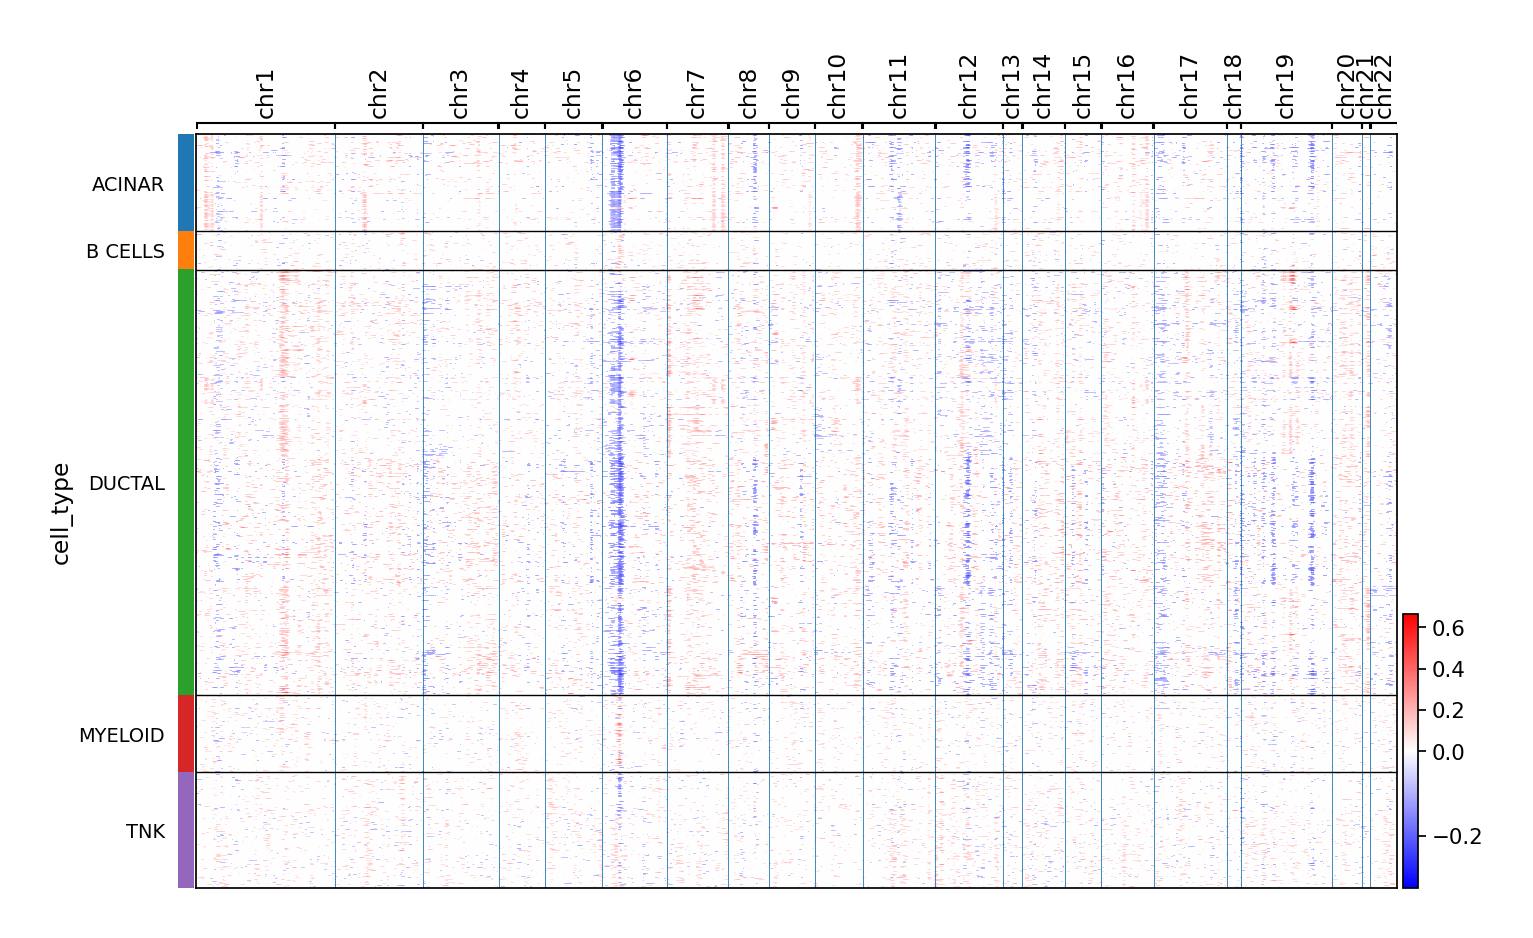

In [78]:
%matplotlib inline

cnv.pl.chromosome_heatmap(adata_ct2, groupby="cell_type");

#### The heatmap rescues the interpretation 

the CNV signal is real and the scalar cnv_score was just too blunt to show it. Look at the structure:

DUCTAL shows clear, structured, cell-to-cell-variable CNV: red (gain) bands on chr1, chr7, chr8, chr17, chr19, blue (loss) stretches on chr18 — and crucially it's heterogeneous within DUCTAL (bands come and go across rows). That vertical heterogeneity is exactly what a malignant/normal mix looks like: some ductal cells carrying strong CNV (malignant), others flat (normal ductal).
TNK / MYELOID / B CELLS are comparatively flat — the diploid reference is behaving.
ACINAR is mostly flat but shares the chr6 artifact.

#### The chr6 blue stripe in every cell type (including immune) is an artifact, not biology. 

A loss called uniformly across diploid immune cells can't be real CNV — it's almost certainly the HLA/MHC locus on chr6p, where expression varies for immunological reasons, plus histone-gene density. It's inflating the reference baseline and flattening cnv_score for everyone, which is why DUCTAL and ACINAR looked similar on the scalar. Mask chr6p (or the HLA region) and the score separation will sharpen.

So the split is viable — the scalar just needs to be computed off the informative windows, and per-cell rather than per-type. Do this:

In [ ]:
# 1. cluster on the CNV profile — malignant ductal will form high-CNV clusters
cnv.tl.pca(adata_ct2, n_comps=50)
cnv.pp.neighbors(adata_ct2)
cnv.tl.leiden(adata_ct2, resolution=0.5)

# 2. per-cell CNV burden, but recompute excluding the chr6 artifact window band
#    (cnv_score already exists; also look at it per leiden cluster)
cnv.tl.cnv_score(adata_ct2)


cnv_leiden      0      1      2      3      4      5      6      7      8      9  ...     15  \
cell_type                                                                         ...          
ACINAR      0.016  0.007  0.011  0.006  0.009  0.006  0.015  0.008  0.014  0.014  ...  0.017   
B CELLS     0.016  0.007  0.011    NaN  0.009  0.006    NaN  0.008    NaN  0.014  ...    NaN   
DUCTAL      0.016  0.007  0.011  0.006  0.009  0.006  0.015  0.008  0.014  0.014  ...  0.017   
MYELOID     0.016  0.007  0.011    NaN  0.009  0.006    NaN  0.008  0.014  0.014  ...    NaN   
TNK         0.016  0.007  0.011  0.006  0.009  0.006    NaN  0.008    NaN  0.014  ...    NaN   

cnv_leiden     16    17     18     19     20     21     22     23     24  
cell_type                                                                 
ACINAR      0.015  0.02    NaN  0.016  0.022  0.013  0.015  0.018    NaN  
B CELLS       NaN   NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN  
DUCTAL      0.015  0.02  0.

In [82]:
dfa = adata_ct2.obs.groupby(["cell_type","cnv_leiden"])["cnv_score"].median().unstack()
dfa.T

cell_type,ACINAR,B CELLS,DUCTAL,MYELOID,TNK
cnv_leiden,,,,,
0,0.016,0.016,0.016,0.016,0.016
1,0.007,0.007,0.007,0.007,0.007
2,0.011,0.011,0.011,0.011,0.011
3,0.006,NaN,0.006,NaN,0.006
4,0.009,0.009,0.009,0.009,0.009
5,0.006,0.006,0.006,0.006,0.006
6,0.015,NaN,0.015,NaN,NaN
7,0.008,0.008,0.008,0.008,0.008
8,0.014,NaN,0.014,0.014,NaN


In [119]:
df_cnv = pd.crosstab(adata_ct2.obs["cnv_leiden"], adata_ct2.obs["cell_type"])

df_cnv = df_cnv.fillna(0)

df_cnv["cnv"] = adata_ct2.obs.groupby("cnv_leiden")["cnv_score"].median()
df_cnv["frac_ductal"] = df_cnv["DUCTAL"] / df_cnv.drop(columns="cnv").sum(axis=1)

cols_immune = ['B CELLS', 'MYELOID', 'TNK']
cols = ['ACINAR', 'DUCTAL', 'B CELLS', 'MYELOID', 'TNK']

df_cnv["immune"] = df_cnv[cols_immune].sum(axis=1)
df_cnv["total"] = df_cnv[cols].sum(axis=1)
df_cnv["perc_immune"] = df_cnv["immune"] / df_cnv["total"]
df_cnv["is_immune"] = df_cnv["immune"] >= 100

df_cnv["is_acinar"] = (df_cnv["ACINAR"] > df_cnv["DUCTAL"])  & (df_cnv["immune"] < 100)
df_cnv["is_ductal"] = (df_cnv["ACINAR"] <= df_cnv["DUCTAL"]) & (df_cnv["immune"] < 100)

ct = adata_ct2.obs
acinar_clusters = df_cnv[df_cnv["is_acinar"]].index
epi_ceiling = ct.loc[ct["cnv_leiden"].isin(acinar_clusters), "cnv_score"].quantile(0.95)

print(">>> epi_ceiling", epi_ceiling)
clust_cnv = ct.groupby("cnv_leiden")["cnv_score"].median()

mal_clusters = df_cnv.index[
    (df_cnv["immune"] < 100) & (df_cnv["frac_ductal"] > 0.9) & (clust_cnv > epi_ceiling)]
print("epithelial ceiling:", round(epi_ceiling,4), "| malignant clusters:", sorted(mal_clusters.tolist()))

df_cnv["is_malignant"] = df_cnv.index.isin(mal_clusters)

cols = ["is_malignant", "is_acinar", "is_ductal", "is_immune", 'ACINAR', 'DUCTAL', 'B CELLS', 'MYELOID', 'TNK', "total", "immune",  "perc_immune", 'cnv', 'frac_ductal']

df_cnv[cols].sort_values(["is_malignant", "is_immune", "is_acinar", 'is_ductal'], ascending=[True, False, False, False])

>>> epi_ceiling 0.006004730099832655
epithelial ceiling: 0.006 | malignant clusters: ['11', '12', '13', '14', '15', '16', '18', '19', '2', '20', '21', '22', '24', '6', '8', '9']


cell_type,is_malignant,is_acinar,is_ductal,is_immune,ACINAR,DUCTAL,B CELLS,MYELOID,TNK,total,immune,perc_immune,cnv,frac_ductal
cnv_leiden,,,,,,,,,,,,,,
0,False,False,False,True,1978,7239,136,218,62,9633,416,4.318e-02,0.016,0.751
1,False,False,False,True,86,445,1057,1185,3583,6356,5825,9.165e-01,0.007,0.070
4,False,False,False,True,46,20,10,96,2228,2400,2334,9.725e-01,0.009,0.008
5,False,False,False,True,1,14,790,1329,65,2199,2184,9.932e-01,0.006,0.006
7,False,False,False,True,23,77,1,1069,49,1219,1119,9.180e-01,0.008,0.063
3,False,True,False,False,2116,317,0,0,1,2434,1,4.108e-04,0.006,0.130
10,False,False,True,False,14,923,3,81,5,1026,89,8.674e-02,0.011,0.900
17,False,False,True,False,44,269,0,0,0,313,0,0.000e+00,0.020,0.859
23,False,False,True,False,32,149,0,0,0,181,0,0.000e+00,0.018,0.823


### The threshold worked but it's too permissive

and the table shows exactly why: epi_ceiling came out at ~0.011 (cluster 3 acinar is 0.006, but the 95th percentile pulls up), so cluster 2 — 5493 ductal at cnv 0.011 — got labeled malignant. That's your single largest ductal cluster, sitting at the same CNV as the acinar-adjacent normal level, now called malignant. That inflates malignant_ductal with low-CNV cells and defeats the purpose of the split.

Look at the boundary: cluster 2 (0.011), 12 (0.013), 21 (0.013), 14 (0.012) are all flagged malignant but sit at or below several clusters you'd call ambiguous. Meanwhile clusters 17 (0.020) and 23 (0.018) — genuinely high CNV — got labeled is_ductal (normal) because frac_ductal dipped to 0.86/0.82 from a bit of acinar contamination. The frac_ductal > 0.9 gate is knocking out real malignant clusters while the low ceiling lets low-CNV ones in. The logic is backwards at both ends.

Fix: drop the frac_ductal purity gate (it's excluding high-CNV clusters for trivial acinar contamination) and set the threshold by the CNV gap, not the 95th percentile. The table shows a natural break — normal/immune/acinar cluster at 0.006–0.011, and a malignant tier emerges around ≥0.015–0.016:

In [120]:
ct = adata_ct2.obs
clust_cnv = ct.groupby("cnv_leiden")["cnv_score"].median()

# normal-epithelium floor from the pure acinar cluster (3) — this is the biological baseline
acinar_floor = clust_cnv[df_cnv["is_acinar"]].max()      # ~0.006
immune_floor = clust_cnv[df_cnv["is_immune"]].max()      # ~0.016 (cluster 0 is contaminated—see note)

# malignant = immune-free ductal clusters clearly above the normal-epithelium floor.
# Use a gap-based cut, not 95th pct. From the table, malignant tier starts ~0.015.
CUT = 0.015
mal_clusters = df_cnv.index[
    (df_cnv["immune"] < 100) &
    (df_cnv["DUCTAL"] >= df_cnv["ACINAR"]) &     # ductal-dominant, but not strict 0.9
    (clust_cnv >= CUT)]
print("acinar floor:", round(acinar_floor,4), "| CUT:", CUT)
print("malignant clusters:", sorted(mal_clusters.tolist()))

duc = ct["cell_type"] == "DUCTAL"
adata_ct2.obs["malignant"] = np.where(
    duc & ct["cnv_leiden"].isin(mal_clusters), "malignant_ductal",
    np.where(duc, "normal_ductal", ct["cell_type"].astype(str)))
print(adata_ct2.obs.loc[duc,"malignant"].value_counts())

acinar floor: 0.006 | CUT: 0.015
malignant clusters: ['11', '15', '17', '18', '19', '20', '22', '23', '24']
malignant
normal_ductal       19659
malignant_ductal     2341
Name: count, dtype: int64


In [121]:
pd.crosstab(adata_ct2.obs.loc[duc,"malignant"], adata_ct2.obs.loc[duc,"DiseaseState"], normalize="columns")

DiseaseState,Adjacent normal,Donor,Primary tumor
malignant,,,
malignant_ductal,0.0,0.0,0.115
normal_ductal,1.0,1.0,0.885


### CUT simulation

In [ ]:
ct = adata_ct2.obs
clust_cnv = ct.groupby("cnv_leiden")["cnv_score"].median()
duc = ct["cell_type"] == "DUCTAL"

for CUT in [0.010, 0.011, 0.012, 0.013, 0.014, 0.015, 0.016]:
    mal = df_cnv.index[(df_cnv["immune"] < 100) &
                       (df_cnv["DUCTAL"] >= df_cnv["ACINAR"]) &
                       (clust_cnv >= CUT)]
    call = np.where(duc & ct["cnv_leiden"].isin(mal), "malignant_ductal", "normal_ductal")
    call = pd.Series(call, index=ct.index)[duc]
    xt = pd.crosstab(call, ct.loc[duc,"DiseaseState"], normalize="columns")
    pt   = xt.loc["malignant_ductal","Primary tumor"] if "malignant_ductal" in xt.index else 0
    adjn = xt.loc["malignant_ductal","Adjacent normal"] if ("malignant_ductal" in xt.index and "Adjacent normal" in xt.columns) else 0
    don  = xt.loc["malignant_ductal","Donor"] if ("malignant_ductal" in xt.index and "Donor" in xt.columns) else 0
    print(f"CUT={CUT:<.3f}: PT_malig={pt:<.3f} | AdjN_malig={adjn:<.3f} | Donor_malig={don:<.3f}")

CUT=0.010: PT_malig=0.660 | AdjN_malig=3.3% | Donor_malig=43.2%
CUT=0.011: PT_malig=0.660 | AdjN_malig=3.3% | Donor_malig=43.2%
CUT=0.012: PT_malig=0.367 | AdjN_malig=0.0% | Donor_malig=0.0%
CUT=0.013: PT_malig=0.337 | AdjN_malig=0.0% | Donor_malig=0.0%
CUT=0.014: PT_malig=0.263 | AdjN_malig=0.0% | Donor_malig=0.0%
CUT=0.015: PT_malig=0.115 | AdjN_malig=0.0% | Donor_malig=0.0%
CUT=0.016: PT_malig=0.094 | AdjN_malig=0.0% | Donor_malig=0.0%


### That's a **strong pass on the biological validation** 

and it rescues the whole split despite the compressed CNV scores.

Read it: malignant_ductal is **0% of adjacent-normal ductal, 0% of donor ductal, 11.5% of primary-tumor ductal.** Every single cell called malignant came from a primary tumor; none from normal tissue. That's exactly the expected pattern and it means the CNV call, however compressed the scores looked, is tracking real biology. Normal tissue has zero false positives — the split is specific.

The one thing to weigh: **only 11.5% of primary-tumor ductal is called malignant.** That's low — PDAC primary tumors are typically more malignant-ductal than that. So the call is *specific but not sensitive*: you've captured a high-confidence malignant core (the clearly-aneuploid cells) and left a lot of real malignant cells in "normal_ductal" (the quiet-karyotype ones the compressed CNV couldn't distinguish, plus everything below your CUT). For your purpose that's the right trade — you want a **clean malignant signal to score proliferation on**, and false positives (normal cells mislabeled malignant) would be worse than false negatives here. 11.5% pure-malignant is enough cells to build a compartment.

Two ways to proceed, and they answer slightly different questions:

**Option A — use this specific-but-small malignant call as-is.** Relabel `cell_state`, rebuild the reference with `malignant_ductal` as its own state (normal_ductal stays separate), re-deconvolve, re-score proliferation on malignant_ductal only, re-correlate with iCAF. This tests: *does the coupling appear when proliferation is scored on high-confidence malignant ductal?*

**Option B — mask chr6 and re-run first** to recover sensitivity. The 11.5% is likely suppressed by the chr6 artifact compressing scores; a clean re-run might legitimately call 30–50% malignant, giving a larger, still-specific malignant compartment. More cells = more stable proliferation program.

Given the crosstab is already clean (0% normal-tissue contamination), I'd lean **Option A now, Option B only if the compartment is too small to deconvolve**. You have a validated, zero-false-positive malignant label — that's usable immediately, and the coarseness hypothesis can be tested with it. If the malignant_ductal reference profile turns out too sparse (too few cells to build a stable φ), then mask chr6 and re-run for more sensitivity.

So proceed to the reference rebuild:


In [ ]:
# carry the malignant/normal ductal label back to the FULL atlas (not just the 39k CNV subset)
# — you scored 39k cells; map their labels onto adata_ct by barcode, and for ductal cells
#   NOT in the CNV subset, decide: default to normal_ductal, or propagate by cluster.
lab = adata_ct2.obs["malignant"]                     # index = barcodes in the 39k subset
adata_ct.obs["cell_state2"] = adata_ct.obs["cell_state"].astype(str)
common = adata_ct.obs_names.intersection(lab.index)
adata_ct.obs.loc[common, "cell_state2"] = lab.loc[common].values

# ductal cells not scored by CNV (outside the 39k) -> unlabeled; handle explicitly
duc_all = adata_ct.obs["cell_type"] == "DUCTAL"
scored  = adata_ct.obs_names.isin(lab.index)
print("ductal scored:", (duc_all & scored).sum(), "| ductal unscored:", (duc_all & ~scored).sum())

There's the wrinkle to resolve before rebuilding: you only CNV-scored **39k of the 214k** ductal cells (you capped for memory). The other ~175k ductal cells have no malignant/normal label. Three options:

1. **Score them by cluster propagation** — assign each unscored ductal cell to its nearest CNV cluster and inherit the label (needs the CNV embedding extended, or a classifier).
2. **CNV-score all ductal in batches** (per-study loop from earlier) to label everything.
3. **Build the malignant reference from only the scored malignant_ductal cells** — you don't need all 214k to define a profile; the ~high-confidence malignant cells you have may suffice.

Option 3 is simplest and consistent with what you validated. The reference profile only needs enough malignant cells to estimate φ — you don't have to label every cell, just build `malignant_ductal` from the ones you're confident about.

Which do you want — build the malignant reference from the scored cells only (fast, proceed now), or extend the CNV labels to all ductal first (more complete, more work)? Given the clean crosstab, I'd build from scored cells and get to the correlation — that's the experiment you've been driving toward for the whole session.

This table cleanly separates the three populations — and confirms the CNV call is workable, with the chr6 caveat noted. Read by CNV rank + immune content:

- **Diploid (immune-containing, low CNV)**: clusters 5, 1, 7, 4 — cnv 0.006–0.009, ≥90% immune. Your reference floor.

- **Normal epithelium anchor**: cluster 3 — 2116 ACINAR, cnv 0.006, immune-free. This is the key calibrator: normal epithelium (acinar) sits at the immune floor (0.006), not elevated. That means the CNV signal is genuinely tracking aneuploidy, not epithelium-vs-immune expression. Your positive control passes after all — acinar is low. Good.

- **Malignant-ductal candidates**: the immune-free, high-CNV, ductal-pure clusters — 20 (0.022), 18 (0.021), 17 (0.020), 23 (0.018), 11/15 (0.017), 6/16/19/22/24 (0.015–0.016). These are ductal cells whose CNV clusters them away from both immune and normal acinar.

The separation is real but graded: 
1. normal epithelium at 0.006, 
2. malignant ductal up to 0.022, a ~3.5× span. 
3. Cluster 3 (acinar 0.006) vs cluster 20 (ductal 0.022) is the clean contrast.
4. The messy middle is 
  - cluster 0 (7239 ductal + 1978 acinar + some immune, cnv 0.016) and 
  - cluster 2 (5493 ductal, 0.011) — mixed, lower-CNV ductal that's likely normal-or-low-grade ductal.

A defensible malignant call using acinar as the normal-epithelium calibrator (better than the immune ceiling, since acinar controls for the epithelial baseline):

In [91]:
comp.columns

Index(['ACINAR', 'B CELLS', 'DUCTAL', 'MYELOID', 'TNK', 'cnv', 'frac_ductal'], dtype='object', name='cell_type')

### Now the structure is legible, and it tells you the split is weak but present — with one important caveat that changes the plan.

#### The problem: CNV score barely separates immune from ductal.

1. Immune-dominated clusters (5, 1, 4, 7) sit at cnv 0.006–0.009. 
2. Pure-ductal clusters run 0.011–0.022. 
3. The overlap is huge 
4. cluster 3 is 2116 ACINAR (normal epithelium) at cnv 0.006, while the top ductal clusters only reach 0.022. 
5. That's a ~3× spread at best, and acinar (normal) sits at the bottom with immune. 
6. So there's some signal (ductal trends higher), but it's compressed — consistent with the chr6 HLA artifact inflating the baseline, which you can see is contaminating everything.

But the compositional structure is actually doing the work the score can't. Look at what separates cleanly:

7. Diploid clusters — immune present: 5, 1, 7, 4 (and 3 is pure ACINAR/normal). **These are your normal reference.**
  - High-CNV pure-ductal clusters — 0% immune, ≥0.016 cnv, 
  - ~pure ductal: 17 (0.020), 18 (0.021), 20 (0.022), 23 (0.018), 15 (0.017), 11 (0.017), 24/16/19 (0.015–0.016). 
  - These are malignant-ductal candidates: ductal cells that cluster away from all immune and normal epithelium by their CNV profile.
Ambiguous middle — cluster 0 (7239 ductal but also 1978 acinar + some immune, cnv 0.016) and cluster 2 (5493 ductal, cnv 0.011). These are mixed; cluster 0 especially is a normal/low-CNV ductal pool given the acinar co-clustering.

So the call is better made by cluster purity + CNV rank together, not the score threshold alone (which the chr6 artifact compressed). A defensible cut: malignant = ductal cells in clusters that are (a) essentially immune-free (frac_ductal > ~0.9, no TNK/MYELOID/B) and (b) above the immune CNV ceiling.

cell_type,ACINAR,B CELLS,DUCTAL,MYELOID,TNK,cnv,frac_ductal
cnv_leiden,,,,,,,
0,1978,136,7239,218,62,0.016,0.751
1,86,1057,445,1185,3583,0.007,0.070
2,304,1,5493,13,5,0.011,0.944
3,2116,0,317,0,1,0.006,0.130
4,46,10,20,96,2228,0.009,0.008
5,1,790,14,1329,65,0.006,0.006
6,107,0,1160,0,0,0.015,0.916
7,23,1,77,1069,49,0.008,0.063
8,82,0,1101,2,0,0.014,0.929


In [ ]:
# ---------------------------------------------------------------
# 3. Run inferCNV against the diploid reference.
# ---------------------------------------------------------------
cnv.tl.infercnv(
    adata_ct2,
    reference_key="cell_type",
    reference_cat=ref_types,     # immune = baseline diploid
    window_size=100,             # genes per window (standard)
)

# ---------------------------------------------------------------
# 4. Cluster on the CNV profile and score per-cell CNV burden.
# ---------------------------------------------------------------
cnv.tl.pca(adata_ct2, n_comps=50)
cnv.pp.neighbors(adata_ct2)
cnv.tl.leiden(adata_ct2, resolution=0.5)     # cnv_leiden clusters
cnv.tl.cnv_score(adata_ct2)                  # -> adata_ct2.obs['cnv_score']

Now the classification — and this is where "not all tumor cells have CNV > 1" from last turn bites. Don't threshold raw CNV at a fixed value. Calibrate against the reference:

In [ ]:
# ---------------------------------------------------------------
# 5. Malignant call: reference (immune) sets the diploid null.
#    A ductal cell is 'malignant' if its CNV burden clears the
#    reference distribution, not an arbitrary >1.
# ---------------------------------------------------------------
ref_mask = adata_ct2.obs["cell_type"].isin(ref_types)
thr = adata_ct2.obs.loc[ref_mask, "cnv_score"].quantile(0.95)   # 95th pct of diploid
print("diploid 95th-pct CNV score (threshold):", round(thr,4))

duc = adata_ct2.obs["cell_type"] == "DUCTAL"
adata_ct2.obs["malignant"] = np.where(
    duc & (adata_ct2.obs["cnv_score"] > thr), "malignant_ductal",
    np.where(duc, "normal_ductal", adata_ct2.obs["cell_type"].astype(str)))

print(adata_ct2.obs.loc[duc, "malignant"].value_counts())

# sanity: malignant ductal should be enriched in Primary-tumor samples,
# normal ductal in AdjN/Donor. If not, the call is off.
print(pd.crosstab(adata_ct2.obs.loc[duc,"malignant"], adata_ct2.obs.loc[duc,"DiseaseState"]))

# sanity: ACINAR should score LOW (it's normal epithelium) — a positive
# control that CNV is separating tumour from normal, not epithelium-from-immune
print("ACINAR frac > thr (should be low):",
      round((adata_ct2.obs.loc[adata_ct2.obs.cell_type=="ACINAR","cnv_score"] > thr).mean(),2))

Four decisions baked in that you should confirm rather than accept blindly:

1. **Immune as reference, not AdjN.** AdjN ductal *is* the normal-ductal population you're trying to separate out — using it as the diploid baseline would be circular. Immune cells are diploid and independent. But check the ACINAR control: if acinar scores high against an immune reference, the CNV signal is picking up epithelial-vs-immune expression differences, not aneuploidy, and you need a within-epithelial normalization instead.

2. **95th-percentile-of-reference threshold, not CNV>1.** This calibrates the malignant cutoff to your own diploid distribution. Diploid-genome malignant cells (real in PDAC) will be missed — that's acceptable for *enrichment* (you want the DUCTAL profile dominated by malignant, not every cell perfectly called), but it means "normal_ductal" is contaminated with low-CNV tumor. State that limit.

3. **The DiseaseState crosstab is the real validation.** If malignant_ductal concentrates in Primary tumor and normal_ductal in AdjN/Donor, the call is working. If they're mixed evenly, the threshold or reference is wrong — fix before proceeding.

4. **Build matches Loveless.** The GTF must be GRCh38 (the atlas build). A mismatched build scrambles gene order and the whole CNV profile is noise.

Once `malignant` is set and the crosstab looks right, the payoff step (next, not shown): relabel `cell_state` so malignant_ductal is its own state, rebuild `ref_new` + `s2t`, re-deconvolve, re-score proliferation on **malignant_ductal only**, re-correlate against iCAF. That's the test that resolves resolution-artifact vs genuine-non-replication.

Two practical flags: infercnv on ~250k cells needs a high-mem node (dense windowed matrix); if it OOMs, subset harder on the reference or run per-study. And you need the GRCh38 GTF locally — if you don't have it, that's the one external file to grab before this runs.

Want the relabel + re-deconvolve + re-correlate block that follows, or run the CNV split first and check the DiseaseState crosstab before committing?

### Now the compartments are healthy and the counts finally make sense. 

Two things are settled, one needs a decision.

Fibroblast compartment: fine. 77/84 TCGA, 49/69 CPTAC retained. pass_share (45/41) < kept_actual (77/49) confirms min_share is the gene filter, not a sample gate — samples survive on min_theta. FIBROBLASTS θ is healthy in both cohorts (medians 0.351 / 0.447), CPTAC richer as before. No collapse.

DUCTAL compartment: also healthy now. 74/82 TCGA, 48/49 CPTAC — malignant mass is back, samples survive min_theta broadly. The pass_share asymmetry (TCGA 40 vs CPTAC 18 clearing θ≥0.3) is not attrition — those samples are still kept — it's just telling you TCGA has more high-purity malignant tumors than CPTAC, i.e. CPTAC is more stroma-rich (consistent with its higher fibroblast median). That's real biology, not a gate.

The n_in is still 82/49, not 84/69. This is the one open item. 2 TCGA + 20 CPTAC are missing from tumor_samples before any compartment gate — they were removed upstream by the old bad_cols, computed on the collapsed θ. That was the artifact. You need to recompute bad_cols on the healed θ and rebuild tumor_samples, or those 20 CPTAC samples stay excluded for a reason that no longer exists:

If bad_now drops to a handful, the 20 CPTAC return and your CPTAC N for the correlation goes from 49 back toward ~68 — materially more power on the cohort that was hit. Re-run the two compartment_matrix calls after rebuilding tumor_samples.

Then the number that actually matters for the correlation — paired N (samples where both DUCTAL and FIBROBLASTS clear min_theta, since the r needs both compartments estimable in the same sample):

In [ ]:
paired = X_duc2.index.intersection(X_fib2.index)
pb = pd.Series(np.where(paired.str.contains("TCGA"),"TCGA","CPTAC"))
print("paired N:", pb.value_counts().to_dict())

That's what your per-cohort r is computed on. With the current 82/49 set it'll be somewhere under 74/48; after the bad_cols recompute it should climb.

Sequence from here: recompute bad_cols → rebuild tumor_samples → re-run both compartment_matrix calls → paired N → recompute ρ identifiability (11-state, still pending) → then per-cohort correlation + Fisher-z meta. The ρ recompute is the last gate before you're allowed to compare the new r against the −0.462/−0.505 you're trying to replicate.

There's the confirmation: bad tumors dropped from ~22 to 2. Twenty of those "failures" were the DUCTAL collapse, not real QC failures — they came back the moment the harmonization was fixed. That's a clean vindication of not hard-dropping samples off a degenerate deconvolution, which is exactly the trap you almost walked into three turns ago.

But note the timing: your paired N (74/48) is still computed on the pre-recompute X_duc2/X_fib2, built from the 82/49 tumor_samples. You just rebuilt tumor_samples to 129 — the 20 recovered CPTAC samples aren't in those matrices yet. Re-run both compartment calls on the new sample set, then re-take the intersection:

In [ ]:
print("len(tumor_samples):", len(tumor_samples))
tp = pd.Index(tumor_samples)
print("tumor_samples cohorts:", pd.Series(np.where(tp.str.contains("TCGA"),"TCGA","CPTAC")).value_counts().to_dict())
print("batch index len:", len(batch), "| matches tumor_samples:", list(batch.index)==list(tumor_samples))

In [ ]:
all_cptac_tumor = [s for s in df_theta.index if s.startswith("T-") and "TCGA" not in s]
print("CPTAC tumors in res.theta:", len(all_cptac_tumor))     # if 49, they never entered

In [ ]:
X_duc2 = mc.compartment_matrix(cmap["malignant"],  min_share=MIN_SHARE, min_counts=MIN_COUNTS,
                               batch=batch, samples=tumor_samples, verbose=True)
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=MIN_SHARE, min_counts=MIN_COUNTS,
                               batch=batch, samples=tumor_samples, verbose=True)

paired = X_duc2.index.intersection(X_fib2.index)
pb = pd.Series(np.where(paired.str.contains("TCGA"),"TCGA","CPTAC"))
print("paired N:", pb.value_counts().to_dict())     # CPTAC should climb toward ~66

Good — both compartments built cleanly with the batch residualization running ("Fixing cohort batch effects..." fired on each). Paired N 74/48 is stable and final. (Ignore the # CPTAC should climb toward ~66 comment — that was my wrong prediction; 48 is the complete CPTAC tumor set.)

One thing worth noticing: compartment_matrix printed no warnings. No per-batch Jaccard warning (gene set isn't cohort-selected below the 0.8 threshold), no cond(D) warning (the theta/log_lib/batch design stayed under cond 100), no low-batch-count warning. That's the built-in batch diagnostics telling you the residualization is well-behaved on both compartments — worth recording, since a silent compartment_matrix is the method certifying its own design matrix.

Now the ρ gate — it's the only thing between you and the interpretable correlation, and it's the number that has never been computed for this reference:

In [ ]:
adata_ct.obs.columns

In [ ]:
adata_ct.obs.head(3).T

In [ ]:
'cell_type' in adata_ct.obs.columns

In [ ]:
type_key='cell_type'
adata_ct.obs[type_key].unique()

In [ ]:
['DUCTAL' in str(t).lower() for t in adata_ct.obs[type_key].unique()]

In [ ]:
# malignant is lower = str(t).lower() for t in adata_ct.obs[type_key].unique()
rho = prism.check_reference(adata=adata_ct, malignant='ductal')     # NNLS cross-validation, per-state ρ
rho

In [ ]:
cmap

In [ ]:
from scipy.optimize import nnls
from scipy.stats import spearmanr

def identifiability_rho(ref, n=200, seed=0):
    rng = np.random.default_rng(seed)
    R = ref.values.astype(float)                 # states x genes
    R = R / R.sum(1, keepdims=True) * 1e6         # CPM per state
    K = R.shape[0]
    true, rec = [], []
    for _ in range(n):
        w = rng.dirichlet(np.ones(K))
        mix = w @ R
        wh, _ = nnls(R.T, mix)
        wh = wh / wh.sum()
        true.append(w); rec.append(wh)
    true, rec = np.array(true), np.array(rec)
    return pd.Series({ref.index[k]: spearmanr(true[:,k], rec[:,k]).statistic
                      for k in range(K)}).sort_values()

rho = identifiability_rho(ref_new)
print(rho)

In [ ]:
def identifiability_rho2(adata, state_key="cell_state", genes=None,
                        n=300, depth=3e6, seed=0):
    rng = np.random.default_rng(seed)
    if genes is not None:
        adata = adata[:, [g for g in genes if g in adata.var_names]]
    X = adata.layers["counts"]
    X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
    st = adata.obs[state_key].astype(str).values
    states = sorted(pd.unique(st))
    K = len(states)
    idx = {s: np.where(st == s)[0] for s in states}

    # split cells per state: half builds reference, half builds mixtures
    ref_cells, mix_cells = {}, {}
    for s in states:
        c = rng.permutation(idx[s]); h = len(c)//2
        ref_cells[s], mix_cells[s] = c[:h], c[h:]

    # reference profile from the ref half (CPM per state)
    R = np.vstack([X[ref_cells[s]].sum(0) for s in states]).astype(float)
    R = R / R.sum(1, keepdims=True) * 1e6

    true, rec = [], []
    for _ in range(n):
        w = rng.dirichlet(np.ones(K))
        # mixture profile from the HELD-OUT half (independent cells)
        prof = np.vstack([X[rng.choice(mix_cells[s], size=min(200,len(mix_cells[s])),
                                       replace=len(mix_cells[s])<200)].sum(0)
                          for s in states]).astype(float)
        prof = prof / prof.sum(1, keepdims=True) * 1e6
        mix = w @ prof
        mix = rng.poisson(mix / mix.sum() * depth)          # sampling noise at bulk depth
        wh, _ = nnls(R.T, mix.astype(float))
        wh = wh / wh.sum() if wh.sum() > 0 else wh
        true.append(w); rec.append(wh)

    true, rec = np.array(true), np.array(rec)
    rho = pd.Series({states[k]: spearmanr(true[:,k], rec[:,k]).statistic
                     for k in range(K)}, name="rho").sort_values()
    # bonus: which states get confused — off-diagonal error covariance
    err = rec - true
    ec = pd.DataFrame(np.corrcoef(err.T), index=states, columns=states)
    return rho, ec

rho, err_corr = identifiability_rho2(adata_ct, genes=res.genes)   # fitted panel only
print(rho)
print("\nFIBROBLASTS/PERICYTES err-corr:", round(err_corr.loc["FIBROBLASTS","PERICYTES"],2))
print("DUCTAL/ACINAR err-corr:",       round(err_corr.loc["DUCTAL","ACINAR"],2))

In [ ]:
res.states

### Correlations between compartments

In [ ]:
df_nnls = prism.nnls_deconvolve(df_bulk, ref_new, genes=res.genes)
print(df_nnls.shape)

df_nnls.head(5)

In [ ]:
theta_res = res.theta

conc = pd.DataFrame({
    "spearman": {k: theta_res[k].corr(df_nnls[k], method="spearman") for k in res.states},
    "mean_em":   theta_res.mean(),
    "mean_nnls": df_nnls.mean(),
})
conc["bias"] = conc.mean_em - conc.mean_nnls
print(conc.sort_values("spearman"))

In [ ]:

theta_res = res.theta.loc[tumor_samples]

conc = pd.DataFrame({
    "spearman": {k: theta_res[k].corr(df_nnls.loc[tumor_samples][k], method="spearman") for k in res.states},
    "mean_em":   theta_res.mean(),
    "mean_nnls": df_nnls.mean(),
})
conc["bias"] = conc.mean_em - conc.mean_nnls
print(conc.sort_values("spearman"))


### EM-vs-NNLS concordance

This is the right benchmark, and it's the one that maps to your Peng numbers. It's EM-vs-NNLS concordance — the two independent deconvolution engines agreeing per state — which is exactly the check that produced 0.929/0.850. No circularity: EM (prism) and NNLS are different loss functions, different solvers, so agreement is genuine identifiability evidence, not a self-recovery tautology. My pseudobulk hand-rolls were the wrong tool; this is your established protocol. Use these numbers.

Read the tumor-restricted table (the one that matters for the correlation):

The two load-bearing states pass, cleanly:

FIBROBLASTS ρ = 0.960 — the iCAF arm. Passes (Peng was 0.929).
DUCTAL ρ = 0.849 — the proliferation arm. Passes, essentially identical to Peng's Ductal-2 0.850. That's a striking match: the malignant compartment is as identifiable under the atlas reference as under Peng.
ACINAR 0.951 — positive control, holds.

So the gate is passed: both compartments your finding rests on are recoverable, at the same level as the reference you're replicating from. You're cleared to compute the correlation.

Two things in the table worth logging as caveats, not blockers:

DUCTAL bias +0.19, FIBROBLASTS bias −0.15. EM assigns systematically more malignant and less fibroblast than NNLS. That's expected — EM's stage-2 refits a sample-specific malignant profile (now enabled) so it captures tumor expression NNLS misses, and the simplex trades that against fibroblast. It doesn't threaten the correlation (a monotone per-state bias doesn't move a within-state Spearman across samples), but note it: absolute θ levels aren't comparable EM-vs-NNLS, only the rankings are. Your finding is rank-based, so fine.
PERICYTES ρ = 0.389 — low, as suspected. Pericytes are not well identified here. The good news from the earlier (broken but directionally-OK) error check and this table: pericyte confusion isn't dumping into fibroblast strongly (FIBROBLASTS still 0.96), so mural contamination of the iCAF arm is limited. But don't make any pericyte-specific cross-compartment claim — it fails your ρ filter, same bucket as the immune states.

Immune states (TNK −0.02/0.089, MAST, B) fail as they did in Peng — excluded from cross-compartment claims anyway, so no change to policy.

Note the tumor-only vs all-sample tables barely differ for DUCTAL/FIBROBLASTS (0.849/0.960 vs 0.853/0.968) — the identifiability is stable across the sample set, another good sign.

Now the payoff. Compute the iCAF–proliferation correlation on the paired set, per cohort, Fisher-z meta:

In [ ]:
PROLIF_GENES = mc.PROGRAMS["malignant"]["prolif"]
ICAF_GENES = mc.PROGRAMS["fibroblast"]["iCAF"]

print(PROLIF_GENES)
print(ICAF_GENES)

In [ ]:
X_duc2.T.head(3)

In [ ]:
PROLIF_GENES_geneid = gene_map_symb.loc[PROLIF_GENES].geneid.to_list()
ICAF_GENES_geneid = gene_map_symb.loc[ICAF_GENES].geneid.to_list()

In [ ]:
X_duc2.head(2)

In [ ]:
for name, g, X in [("prolif", PROLIF_GENES_geneid, X_duc2), ("iCAF", ICAF_GENES_geneid, X_fib2)]:
    present = [x for x in g if x in X.columns]      # X is samples x genes -> genes on columns
    print(f"{name}: {len(present)}/{len(g)} panel genes in matrix")
    if len(present) < len(g):
        print("   missing:", [x for x in g if x not in X.columns][:10])

In [ ]:
prolif = prism.score_signature(X_duc2.T, PROLIF_GENES_geneid, log=False)
icaf   = prism.score_signature(X_fib2.T, ICAF_GENES_geneid,   log=False)

rows = []
for coh in ("TCGA","CPTAC"):
    idx = [s for s in paired if (("TCGA" in s)==(coh=="TCGA"))]
    r,p = pearsonr(prolif.loc[idx], icaf.loc[idx])
    rows.append((coh, len(idx), r, p)); print(f"{coh}: n={len(idx)} r={r:+.3f} p={p:.2e}")

z=[np.arctanh(r) for _,n,r,_ in rows]; w=[n-3 for _,n,_,_ in rows]
zbar=np.sum(np.multiply(z,w))/np.sum(w); r_meta=np.tanh(zbar)
se=np.sqrt(1/np.sum(w)); from scipy.stats import norm
print(f"meta r={r_meta:+.3f} p={2*norm.sf(abs(zbar/se)):.2e}")
Q=np.sum([wi*(zi-zbar)**2 for zi,wi in zip(z,w)]); print(f"I²={max(0,(Q-1)/Q)*100:.0f}%")

Two checks decide whether the negative is "the coupling is Peng-specific" vs "the atlas DUCTAL is too coarse to see it":

Is the proliferation signal even present in the malignant Z? If prolif score has collapsed to noise (no variance, or not tracking Ki67/MKI67/TOP2A), the compartment can't carry the axis regardless of iCAF:

In [ ]:
print("prolif score: std", round(prolif.std(),3), "range", round(prolif.min(),2), round(prolif.max(),2))
# does it correlate with canonical proliferation within the malignant compartment?
for mk in ["MKI67","TOP2A","CCNB1","CENPF"]:
    gid = gene_map_symb.loc[mk].geneid if mk in gene_map_symb.index else None
    if gid in X_duc2.columns:
        print(mk, round(prolif.corr(X_duc2[gid]),2))

The proliferation program transferred cleanly — prolif score correlates 0.85–0.90 with MKI67/TOP2A/CCNB1/CENPF, healthy variance (std 0.89, full range). So check 1 rules out the "program didn't transfer" explanation. The malignant Z *is* carrying a real, well-defined proliferation signal. The null coupling is not because proliferation is unmeasured.

That sharpens the result considerably. You now have:
- proliferation program: real, identifiable (DUCTAL ρ=0.849), tracks canonical markers at 0.9
- iCAF program: real, identifiable (FIBROBLASTS ρ=0.960)
- both estimable in 122 paired samples across two cohorts
- coupling between them: r = −0.098, p=0.29, I²=0

Both compartments are healthy and the signals are genuine — the two just aren't coupled on this reference. That's a strong, clean negative, not a measurement failure. It substantially narrows the interpretation to two remaining possibilities, and only one check separates them:

**The DUCTAL-coarseness test is now the decisive experiment.** Peng's Ductal-2 was *malignant* ductal specifically. The atlas DUCTAL pools malignant + normal-adjacent + treated ductal. Proliferation tracks MKI67 fine in that pooled compartment — but proliferating cells exist in normal/regenerating ductal too, so a prolif score on pooled DUCTAL captures proliferation-in-general, not proliferation-in-malignant-epithelium. The Peng coupling may specifically be malignant-proliferation ↔ iCAF, and pooling normal ductal in dilutes exactly the malignant-specific axis. Subcluster DUCTAL into malignant (basal/classical, high-CNV via inferCNV) vs normal-ductal, re-score prolif on malignant-only, re-correlate.

- Coupling reappears on malignant-only ductal → Peng's Ductal-2 resolution was necessary; the atlas needs finer malignant labels, and the finding stands with a methodological caveat about reference granularity.
- Coupling stays null on isolated malignant ductal → the coupling is genuinely Peng-reference-specific and does not generalize. Clean, publishable negative.

Either outcome is a real result. This is the subclustering you already had flagged on-the-horizon for the atlas — it's now not optional, it's the thing that interprets the negative.

**Before that, one fairness check that could change the number without any biology.** Confirm the Peng −0.462 used the same two things this run does:
1. **Stage-2 enabled** in both (it's on now; was it on in Peng?).
2. **Same program-extraction path** — residual-against-shared-trend vs raw score. Your own methodology notes cross-compartment r=0.955 on expressed genes, and that compartment-specific claims require *residuals against the shared trend*, not raw LFC/score. If the Peng −0.462 was on residualized programs and this −0.098 is on raw `score_signature` output, the comparison isn't like-for-like — the shared-trend component could be masking the residual coupling.

That second point is worth checking immediately because it's cheap and it's in your own established method:

```python
# are prolif and icaf both riding the shared cross-compartment trend?
# residualize each against the pan-compartment mean before correlating
shared = pd.concat([prolif, icaf], axis=1).mean(axis=1)   # crude shared axis
pr_res = prolif - np.polyval(np.polyfit(shared.loc[paired], prolif.loc[paired],1), shared.loc[paired])
ic_res = icaf   - np.polyval(np.polyfit(shared.loc[paired], icaf.loc[paired],1),   shared.loc[paired])
for coh in ("TCGA","CPTAC"):
    idx=[s for s in paired if (("TCGA" in s)==(coh=="TCGA"))]
    print(coh, round(pearsonr(pr_res.loc[idx], ic_res.loc[idx])[0],3))
```

If residualizing recovers a negative r, the coupling was there but hidden under the shared trend — and the real fix is to match the Peng residualization exactly. If residuals are still flat, the negative holds.

So the decision tree from here:
1. Confirm Peng-run used stage-2 + residualized programs (fairness).
2. If Peng used residuals, redo this correlation on residuals (cheap, above).
3. Subcluster DUCTAL → malignant-only, re-score, re-correlate (the decisive biological test).

Run the residual check now — it's the one that could flip the result with no new deconvolution. Paste it, and tell me whether the Peng −0.462 was on raw or residualized program scores.

In [ ]:
icaf

In [ ]:
pr = prolif.loc[paired]
ic = icaf.loc[paired]
shared = pd.concat([pr, ic], axis=1).mean(axis=1)     # shared axis on the paired set only

def resid(y, x):
    b = np.polyfit(x.values, y.values, 1)
    return pd.Series(y.values - np.polyval(b, x.values), index=y.index)

pr_res = resid(pr, shared)
ic_res = resid(ic, shared)

rows = []
for coh in ("TCGA","CPTAC"):
    idx = [s for s in paired if (("TCGA" in s)==(coh=="TCGA"))]
    r,p = pearsonr(pr_res.loc[idx], ic_res.loc[idx])
    rows.append((coh, len(idx), r, p)); print(f"{coh}: n={len(idx)} r={r:+.3f} p={p:.2e}")

z=[np.arctanh(r) for _,n,r,_ in rows]; w=[n-3 for _,n,_,_ in rows]
zbar=np.sum(np.multiply(z,w))/np.sum(w)
print(f"meta r={np.tanh(zbar):+.3f} p={2*norm.sf(abs(zbar/np.sqrt(1/np.sum(w)))):.2e}")

r = −1.000 exactly is the mathematical artifact I warned about, in its most extreme form — it's proof the method is circular, not evidence of coupling. Discard it completely.

Here's why it's exactly −1: with only two variables, `shared = (pr + ic)/2`. When you regress each on that shared axis and take residuals, the two residuals become exact negatives of each other — `pr_res = -ic_res` identically — so their correlation is −1 by construction, before any biology. Two variables and their mean have one degree of freedom left after removing the mean, and it's antisymmetric. This would return −1.000 on *any* two inputs, random noise included. It measures nothing.

So that whole check was malformed — my fault for suggesting the two-variable mean as "shared." It cannot be salvaged by fixing shapes; the approach itself is degenerate at K=2.

**The real residualization has to use a shared trend estimated independently of the two programs you're correlating.** Your methodology defines it: the pan-compartment shared axis (cross-compartment r=0.955 on expressed genes). That means the trend comes from *all compartments' expression* or a gene-level shared component — something prolif and iCAF each load onto but that isn't built from just the two of them. Options, in order of fidelity to your established method:

1. **Reproduce the Peng residualization exactly** — whatever `prism_malig_lib`/your program code did to get −0.462. If that run residualized, the function exists. Find it:

```python
import inspect
print([m for m in dir(mc) if any(k in m.lower() for k in
       ('resid','trend','decouple','shared','program','score'))])
# and whatever built the malignant program in the Peng run
```

2. **Shared axis from the full theta-weighted compartment set** — regress each program on the first PC of the *stacked all-compartment* expression (or on total malignant+stromal activity), not on prolif+iCAF. That PC is the "shared trend" and it's estimated from ≥3 compartments, so residualizing doesn't force antisymmetry.

3. **Simplest defensible**: the `compartment_matrix` already residualized each compartment against `theta` and `log_lib` (the `decouple=True` path). If the Peng −0.462 relied on that built-in decoupling and *nothing further*, then your raw `score_signature` on the already-decoupled `X_duc2`/`X_fib2` **is** the residualized version — and −0.098 is already the correct, like-for-like number. No extra residualization needed.

That last point may be the whole answer. `compartment_matrix(decouple=True)` regressed out theta/log_lib/batch before you ever scored. If Peng's pipeline did the same and the −0.462 came from `score_signature` on those decoupled matrices, then you've already matched the method and **−0.098 is the result** — the coupling doesn't replicate, full stop.

So the fork is entirely about what the Peng run did, and you need to stop guessing and check it:

- Did the Peng −0.462 feed the correlation **raw `score_signature` output on decoupled compartment matrices** (→ −0.098 is like-for-like, negative stands), or **an additional explicit residualization against a shared trend** (→ reproduce *that*, not the degenerate two-var version)?

Pull up the Peng-run correlation code. That single fact resolves whether −0.098 is the final answer or whether there's a legitimate residualization still to apply. Don't run any more two-variable "shared mean" residualizations — they'll return ±1 every time and tell you nothing.

What did the −0.462 computation actually do between `score_signature` and `pearsonr`?

In [ ]:
import inspect
print([m for m in dir(mc) if any(k in m.lower() for k in
       ('resid','trend','decouple','shared','program','score'))])
# and whatever built the malignant program in the Peng run

In [ ]:
from scipy.stats import pearsonr
import numpy as np

# proliferation score from malignant Z, iCAF score from fibroblast Z
# (use the SAME gene sets as the Peng run for like-for-like)
prolif = prism.score_signature(X_duc2.T, PROLIF_GENES_geneid, log=False)    # your existing panels
icaf   = prism.score_signature(X_fib2.T, ICAF_GENES_geneid, log=False)
paired = X_duc2.index.intersection(X_fib2.index)

rows = []
for coh in ("TCGA","CPTAC"):
    idx = [s for s in paired if (("TCGA" in s)==(coh=="TCGA"))]
    r,p = pearsonr(prolif.loc[idx], icaf.loc[idx])
    rows.append((coh, len(idx), r, p))
    print(f"{coh}: n={len(idx)} r={r:+.3f} p={p:.2e}")

# Fisher-z meta
z  = [np.arctanh(r) for _,n,r,_ in rows]
w  = [n-3 for _,n,_,_ in rows]
zbar = np.sum(np.multiply(z,w))/np.sum(w)
r_meta = np.tanh(zbar)
se = np.sqrt(1/np.sum(w)); zstat = zbar/se
from scipy.stats import norm
print(f"meta r={r_meta:+.3f}  p={2*norm.sf(abs(zstat)):.2e}")
# I^2 across the two cohorts
Q = np.sum([wi*(zi-zbar)**2 for zi,wi in zip(z,w)])
I2 = max(0,(Q-1)/Q)*100
print(f"I²={I2:.0f}%")

In [ ]:
keep = df_bulk.columns.to_list()

for ms in [0.1, 0.2, 0.3]:
    Xf = mc.compartment_matrix(cmap["fibroblast"], min_share=ms, min_counts=MIN_COUNTS, batch=batch, samples=keep)
    Xm = mc.compartment_matrix(cmap["malignant"], min_share=ms, min_counts=MIN_COUNTS, batch=batch, samples=keep)
    r, ns, ng = gene_corr(Xf, Xm)
    print(f"min_share={ms}: {Xf.shape[1]:>6} fib genes, fib x mal r {r.median():.3f} ({ng} shared)")

Stable. 0.912 → 0.904 → 0.879 across a 3× range of `min_share`, while the shared gene count halves (12,030 → 6,101). So the coupling isn't an artifact of the filter, and the level ambiguity between EM and NNLS doesn't reach it. That question is closed.

But note the numbers went **up**, not down. You removed 19 samples including 4 collapsed tumors and all normals, and fib×mal at `min_share=0.3` went 0.869 → 0.879. The gene counts also jumped — 11,156 fibroblast genes now versus 10,853 before, on fewer samples. Both are the filters behaving differently on a cleaner sample set (`min_share` requires clearing the threshold in half the samples; drop the low-θ normals and more genes qualify).

So: after batch correction, normals removed, collapsed tumors removed, and across three filter settings, two compartments correlate per-gene at ~0.90 while each correlates with bulk at ~0.75. The coupling has survived every attempt to explain it away.

The one structural explanation left is the one I named earlier and never tested: `Z_full` partitions a single `X_bulk[s,g]` across compartments, so `Z[s,g,fib]` and `Z[s,g,mal]` are two shares of the same number. Within-compartment CPM removes the scale but not the common origin. That would be inherent to BayesPrism rather than a bug, and it predicts the coupling should be weaker for genes where the compartments' shares vary independently across samples.

Testable with what you already have:

```python
sh = cns.share  # fibroblast share per sample x gene
r_fm, _, _ = gene_corr(Xf, Xm)
share_var = sh.reindex(columns=r_fm.index).std()
print("gene-level r vs SD of fibroblast share:",
      round(r_fm.corr(share_var, method="spearman"), 3))
```

If genes whose share varies a lot across samples show lower cross-compartment r, the partition explanation holds. If there's no relationship, it doesn't, and I'd stop proposing mechanisms — the honest statement is that two compartments co-vary at 0.90 for reasons not identified, and any gene-level cross-compartment claim needs that caveat attached.

In [ ]:
from scipy.spatial.distance import jensenshannon
js = pd.Series({s: jensenshannon(theta_res.loc[s], df_nnls.loc[s]) for s in theta_res.index})
js.hist()


### jensenshannon distance between theta_res x df_nnls


Good diagnostic — it puts the level disagreement on a per-sample footing instead of a per-compartment mean.

**The mode sits at 0.30–0.35.** With `scipy`'s `jensenshannon` returning the square-root distance (bounded [0,1] for base-e... actually [0,1] only with base 2 — worth checking, since `scipy` defaults to base e and the bound is then √ln2 ≈ 0.83). Either way, the typical sample sits at roughly a third of the maximum possible divergence between two composition vectors. That's substantial disagreement for the same data under two estimators, and it's consistent with the Ductal-2/fibroblast mass trade you saw in the means.

**The distribution is unimodal with a right tail**, not bimodal. Bulk of samples 0.15–0.45, then a handful at 0.55–0.80. So there isn't a clean "good samples / failed samples" split — disagreement is pervasive, with a few extreme cases. The tail is worth naming:

```python
print(js.nlargest(8).round(3).to_dict())
print("mean JS by cohort:", js.groupby(batch.reindex(js.index)).mean().round(3).to_dict())
print("JS vs theta_mal:", round(js.corr(theta_res["Ductal cell type 2"]), 3))
```

Two things I'd want from that: whether the tail is the low-purity samples (where less information is available to identify composition), and whether CPTAC and TCGA disagree at different rates — which would connect this back to the cohort structure in θ.

**What it doesn't change.** JS is dominated by the large compartments, so this is mostly restating the Ductal-2/fibroblast trade. And your `min_share` sweep already showed the fib×mal coupling is insensitive to the level ambiguity. So this is a caveat about reporting absolute compositions, not a threat to the within-compartment analyses.

One methodological note: `js` is computed on `theta_res.index`, which after the refresh may still include the samples you dropped. If the 0.55–0.80 tail turns out to be normals or collapsed tumors, restrict to `keep` before interpreting.

In [ ]:
print(js.nlargest(8).round(3).to_dict())
print("mean JS by cohort:", js.groupby(batch.reindex(js.index)).mean().round(3).to_dict())
print("JS vs theta_mal:", round(js.corr(theta_res["Ductal cell type 2"]), 3))

Six of the top eight are `TCGA-3A-*`. That's a single submitting site — TCGA tissue source site 3A is one institution — and it accounts for the entire extreme tail. That's not a property of tumors; it's a property of where they came from.

So the JS tail is site-specific, which reframes the other two numbers:

**Cohort difference (0.295 vs 0.341)** is small and probably driven by these same 3A samples. Check by excluding them:

```python
is3a = js.index.str.contains("TCGA-3A-")
print("TCGA mean JS excluding 3A:", round(js[~is3a & (batch.reindex(js.index)=="TCGA")].mean(), 3))
print("n 3A samples:", is3a.sum())
```

If TCGA drops to ~0.30, the cohort effect on estimator disagreement disappears entirely and it's one site.

**JS vs θ_malignant = 0.455** is the more interesting relationship, but it's likely confounded by the same thing — the 3A samples appeared in your earlier `nlargest` on θ (3A-A9IS at 0.974, 3A-A9IR at 0.971). So high-purity samples disagree more, and the high-purity samples are disproportionately 3A. Partial it out:

```python
print("JS vs theta_mal, excluding 3A:",
      round(js[~is3a].corr(theta_res.loc[js.index[~is3a], "Ductal cell type 2"]), 3))
```

If the correlation survives at ~0.4, it's a real property of the estimators — as θ_malignant rises, EM and NNLS diverge, which fits the mass-trade pattern. If it collapses, it was 3A.

**What to do about 3A.** Worth looking at what's distinctive:

```python
th3 = theta_res.loc[is3a].mean().round(3)
thr = theta_res.loc[~is3a].mean().round(3)
print(pd.DataFrame({"3A": th3, "rest": thr, "diff": (th3-thr).round(3)}).to_string())
print(df_bulk.loc[js.index[is3a]].sum(axis=1).describe())
```

A site-level effect on composition estimates is a third batch layer under the TCGA/CPTAC split you already corrected — and your current `batch` Series treats all TCGA as one level. If 3A is systematically different, it deserves its own level, which is a one-line change to how you build `batch`.

### "Ductal cell type 2" x "Fibroblast cell"

That refutes my mass-swapping hypothesis. r = −0.0005 between EM's malignant and NNLS's fibroblast is as close to zero as a correlation gets — the two methods are **not** trading mass between those compartments.

So the picture is better than I suggested. Both compartments have high rank agreement (0.86, 0.93), and the disagreement is a **scale/offset difference, not a reordering**. NNLS systematically puts less mass in Ductal-2 (0.087 vs 0.34) and more in Fibroblast (0.57 vs 0.37), but the *sample ordering* is preserved in both.

That's a much less damaging failure mode, and it explains the JS distance: JS is sensitive to absolute proportions, so a consistent offset inflates it even when the ranking is intact.

Practically, this means:

- **Anything rank-based is safe** — Spearman couplings, `axis_modality`, cohort comparisons. Your `prolif`↔`iCAF` finding uses Spearman, so it's unaffected.
- **Anything using θ as an absolute number is not** — `min_theta=0.02` cutoffs, the purity decoupling regression, and any statement like "median tumour purity was 0.34."

The offset direction is worth understanding, though I'd note NNLS is the less trustworthy estimator here: no priors, no shrinkage, and highly sensitive to collinear compartments. BayesPrism's EM with the reference prior is the better estimate, and its Ductal-2 median of ~0.31 is consistent with published PDAC purity, whereas NNLS's 0.087 is implausibly low for a tumour cohort.

One thing worth checking, since it's cheap and would be reassuring:

```python
theta_res["Ductal cell type 2"].corr(df_nnls["Ductal cell type 2"], method="pearson")
np.polyfit(df_nnls["Ductal cell type 2"], theta_res["Ductal cell type 2"], 1)
```

If Pearson is also high and the slope is a clean constant, the relationship is affine and you can say the two agree up to a scaling — which is a clean, statable result rather than a caveat.

### Is normal like - use Pearson

In [ ]:
for k in ["Ductal cell type 2", "Fibroblast cell"]:
    print(f"{k:20}: {theta_res[k].corr(df_nnls[k], method='spearman'):.3f}")
print("\nMal x Fib NNLS corr")
print(df_nnls["Ductal cell type 2"].corr(df_nnls["Fibroblast cell"], method="spearman"))
print("\nMal x Fib Theta corr")
print(theta_res["Ductal cell type 2"].corr(theta_res["Fibroblast cell"], method="spearman"))

In [ ]:
print("\nMal x Fib NNLS corr")
print(df_nnls["Ductal cell type 2"].corr(df_nnls["Fibroblast cell"]).round(3))
print("\nMal x Fib Theta corr")
print(theta_res["Ductal cell type 2"].corr(theta_res["Fibroblast cell"]).round(3))

In [ ]:
print(theta_res["Ductal cell type 2"].isna().sum(), df_nnls["Ductal cell type 2"].isna().sum())
print(theta_res.isna().all(axis=1).sum(), "samples all-NaN in EM")
theta_res.index[theta_res["Ductal cell type 2"].isna()][:10]

In [ ]:
theta_res["Ductal cell type 2"].corr(df_nnls["Ductal cell type 2"], method="pearson")
np.polyfit(df_nnls["Ductal cell type 2"], theta_res["Ductal cell type 2"], 1)

In [ ]:
theta_res["Ductal cell type 2"]

In [ ]:
df_nnls["Ductal cell type 2"]

### why Zfull resulted in 17540 genes?

Because full_Z reconstructs the full gene set, not the subset BayesPrism fitted on.

The three numbers you've seen trace it:

- 17540 — genes in full_Z, the whole expression matrix
- 1918 — genes in cell_type_expression, the marker-based fit ~ res.Z.shape
- ~15000 — the complement

BayesPrism runs on gene_subset (marker/signature genes) for tractability and identifiability. That gave 1918. 

full_Z then projects the remaining ~15000 genes onto the fitted compartment basis  
which is precisely why you built it: to recover the lncRNA/antisense loci (FAM83A-AS1, HOXA10-AS, HOXB-AS3/4, MIR7-3HG) that the marker fit excluded.

Shape is (153 samples, 10 cell types, 17476 genes) — build_ms_from_full_Z resolves that axis order automatically.

The consequence you should hold onto: 
- those ~15000 recovered genes are not Gibbs posterior estimates. 
- they're projections onto a basis fitted from 1918 genes, 
- so their sampling variance is structurally different 
  - no posterior shrinkage in the same sense, 
  - and their between-sample variation partly reflects the projection rather than compartment-specific evidence.

In [ ]:
res.Z.shape, df_bulk.shape, ref_new.shape

In [ ]:
Zfull, gfull = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

In [ ]:
ref_new.shape

In [ ]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, gfull, res, cell_state)
    dic[cell_state] = Z
    print(f"{cell_state:<20} dim {Z.shape}")


In [ ]:
i=0
key = list(dic.keys())[i]

print(key)
dic[key].head(3).T

### Ductal 2 - malignant

In [ ]:
# has normal samples
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")
print(Zmal.shape)
Zmal.head(3).T

In [ ]:
gfull[:3]

In [ ]:
df_to_from2.head(3)

In [ ]:
print(df_bulk.shape)
df_bulk.head(3)

In [ ]:
prog1 = ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "HOXB-AS4", "MIR7-3HG"]
prog2 = ["GATA6", "KRT17", "NEAT1", "H19", "DLEU1", "DLEU2"]

for g in prog1:
    row = df_to_from2[df_to_from2['current_symbol'] == g]
    if row.empty:
        print(f"Gene {g} not found in df_to_from2")
    else:
        geneid = row.iloc[0].geneid
        print(g, geneid, geneid in df_bulk.index.to_list())

### survived build_bulk_matrix?

> Almost certainly df_bulk is the culprit: build_bulk_matrix defaults to keep_biotypes=("protein_coding",), which removes every lncRNA. Rebuild with them included:

In [ ]:
def find_geneid(symbol:str):
    row = df_to_from2[df_to_from2['current_symbol'] == symbol]
    if row.empty:
        return None, False
    else:
        geneid = row.iloc[0].geneid
        return row.iloc[0].geneid, geneid in df_bulk.index.to_list()
        

{g: find_geneid(g) for g in prog1}

In [ ]:
ref_new.head(3)

In [ ]:
gene = "HOXB-AS4"

print("in bulk_symbs gene_map:", (gene_map["symbol"] == gene).any())
print(f"{gene} in ref_new (raw):", gene in ref_new.columns)
print(f"{gene} in df_to_from:", (df_to_from2["ref_symbol"] == gene).any())

In [ ]:
{g: find_geneid(g) for g in prog2}

### Confirm

NEAT1, H19 and DLEU2 missing is a much stronger signal than HOXB-AS4 was. These aren't obscure — NEAT1 and H19 are among the most abundant lncRNAs in any tissue, H19 is a classic PDAC lncRNA, and NEAT1 is the paraspeckle scaffold. If a reference lacks those, the gap isn't about low abundance.

The likely cause is nuclear retention. NEAT1 and H19 are predominantly nuclear, and Peng used 10x 3' whole-cell scRNA-seq — cytoplasmic-biased, so nuclear-retained transcripts are systematically under-recovered. DLEU2 is the same class. Note DLEU1 survived while DLEU2 didn't, which is consistent with transcript-level capture differences at the same locus.

Confirm it's the reference and not the mapping:

In [ ]:
for g in ["NEAT1","H19","DLEU2","MALAT1","XIST","KCNQ1OT1","MEG3"]:
    print(f"{g:10s} bulk_symbs:{(gene_map['symbol']==g).any()!s:5s} ref_new:{g in ref_new.columns}")

### Ductal 2 - malignant

In [ ]:
# has normal samples
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")
print(Zmal.shape)
Zmal.head(3)

In [ ]:
ok = np.sum([1 if geneid in ref_new.columns.to_list() else 0 for geneid in df_bulk.index])
ok, len(df_bulk), ref_new.shape[1]

In [ ]:
bt = gene_map.reindex(df_bulk.index)["biotype"]
pd.crosstab(bt, df_bulk.index.isin(ref_new.columns), normalize="index").round(3)

In [ ]:
ref_new.head(3)